# Harmonizing the Data of Your Data: SDRF Metadata Extraction Pipeline

**Competition:** Harmonizing the Data of Your Data

**Notebook Focus:** Hybrid metadata extraction from proteomics publications via regex rule engine, PRIDE/ProteomeXchange REST API, and LLM inference; ontology-aware harmonization with RapidFuzz fuzzy-snap; automated SDRF table construction per competition schema.

**Author:** [Amey Thakur](https://www.kaggle.com/ameythakur20)

## Table of Contents

1.  [Data Acquisition](#1-data-acquisition)
2.  [Data Inspection](#2-data-inspection)
3.  [Data Cleaning](#3-data-cleaning)
4.  [EDA](#4-eda)
5.  [Feature Engineering](#5-feature-engineering)
6.  [Modeling](#6-modeling)
7.  [Evaluation](#7-evaluation)
8.  [Conclusion](#8-conclusion)
9.  [References](#9-references)

## 1. Data Acquisition

Installs external dependencies, loads standard library and third-party imports, declares global pipeline configuration, and validates dataset path availability via a structured status table.

In [1]:
%%capture
!pip install anthropic rapidfuzz sentence-transformers scikit-learn -q

In [2]:
import os, re, json, warnings
from collections import defaultdict, Counter
from pathlib import Path
from typing import Dict, List

import pandas as pd
import numpy as np
from tqdm import tqdm
from rapidfuzz import fuzz

# ML & Semantic Matching Imports
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder
from sentence_transformers import SentenceTransformer, util

warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────
# Global Configuration 
# ─────────────────────────────────────────────

# API timeouts (seconds)
PRIDE_TIMEOUT   = 12
PX_TIMEOUT      = 12
OLS_TIMEOUT     = 8

# LLM extraction
LLM_ENABLED     = True          # [FLAG] Set False to disable Anthropic calls
LLM_BATCH_SIZE  = 1             # Papers per LLM call
LLM_MAX_CHARS   = 12000         # UPGRADED: Increased from 6000 to capture Methods & Results
LLM_MODEL       = 'claude-sonnet-4-20250514'

# Harmonization thresholds (UPGRADED)
DEFAULT_FUZZY_CUTOFF = 0.80     # Min similarity score for vocab snap
COLUMN_CUTOFFS = {
    'Characteristics[CellLine]': 0.85,  # Stricter for cell lines
    'Characteristics[Disease]': 0.75,   # Looser for diseases
    'Comment[Instrument]': 0.90         # Instruments are highly standardized
}
MULTI_VAL_CAP   = 4             # Max extracted values per base column
FALLBACK_RATIO  = 0.80          # Apply global mode if col present in >80% of train files

# Consensus Voting Weights (NEW)
SOURCE_WEIGHTS = {
    'ground_truth': 1.0,
    'pride_api': 0.8,
    'px_xml': 0.8,
    'llm': 0.7,
    'regex': 0.5
}

# Dataset paths
BASE            = Path('/kaggle/input/competitions/harmonizing-the-data-of-your-data')
TRAIN_SDRF_DIR  = BASE / 'Training_SDRFs'  / 'HarmonizedFiles'
TEST_TEXT_DIR   = BASE / 'Test PubText'    / 'Test PubText'
SAMPLE_SUB_PATH = BASE / 'SampleSubmission.csv'

if not TEST_TEXT_DIR.exists():
    TEST_TEXT_DIR = BASE / 'Training_PubText' / 'PubText'

# Load lightweight biomedical/semantic embedding model (NEW)
try:
    embedder = SentenceTransformer('all-MiniLM-L6-v2')
except Exception:
    embedder = None
    print("Warning: Semantic embedder failed to load. Will fallback to RapidFuzz.")

# ─────────────────────────────────────────────
# Configuration summary 
# ─────────────────────────────────────────────
pd.DataFrame([
    {'parameter': 'PRIDE_TIMEOUT',  'value': PRIDE_TIMEOUT,  'unit': 'seconds'},
    {'parameter': 'PX_TIMEOUT',     'value': PX_TIMEOUT,     'unit': 'seconds'},
    {'parameter': 'OLS_TIMEOUT',    'value': OLS_TIMEOUT,    'unit': 'seconds'},
    {'parameter': 'LLM_ENABLED',    'value': LLM_ENABLED,    'unit': 'bool'},
    {'parameter': 'LLM_BATCH_SIZE', 'value': LLM_BATCH_SIZE, 'unit': 'papers/call'},
    {'parameter': 'LLM_MAX_CHARS',  'value': LLM_MAX_CHARS,  'unit': 'characters'},
    {'parameter': 'LLM_MODEL',      'value': LLM_MODEL,      'unit': 'model id'},
    {'parameter': 'DEFAULT_FUZZY',  'value': DEFAULT_FUZZY_CUTOFF, 'unit': 'ratio [0,1]'},
    {'parameter': 'MULTI_VAL_CAP',  'value': MULTI_VAL_CAP,  'unit': 'values/col'},
    {'parameter': 'FALLBACK_RATIO', 'value': FALLBACK_RATIO, 'unit': 'ratio [0,1]'},
    {'parameter': 'SEMANTIC_MODEL', 'value': 'all-MiniLM-L6-v2', 'unit': 'model id'},
])

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

,parameter,value,unit
0,PRIDE_TIMEOUT,12,seconds
1,PX_TIMEOUT,12,seconds
2,OLS_TIMEOUT,8,seconds
3,LLM_ENABLED,True,bool
4,LLM_BATCH_SIZE,1,papers/call
5,LLM_MAX_CHARS,12000,characters
6,LLM_MODEL,claude-sonnet-4-20250514,model id
7,DEFAULT_FUZZY,0.8,"ratio [0,1]"
8,MULTI_VAL_CAP,4,values/col
9,FALLBACK_RATIO,0.8,"ratio [0,1]"


In [3]:
# ─────────────────────────────────────────────
# Semantic + Lexical Ontology Snapping
# ─────────────────────────────────────────────
import torch
from rapidfuzz import process, fuzz # [FIX]: Imported 'process' here!

def get_cutoff(col_name: str) -> float:
    return COLUMN_CUTOFFS.get(col_name, DEFAULT_FUZZY_CUTOFF)

def semantic_snap(extracted_val: str, col_name: str, vocab: set) -> str:
    """
    Hybrid snapping: Tries exact -> RapidFuzz -> Semantic Cosine Similarity
    """
    extracted_val = str(extracted_val).strip()
    if not extracted_val or not vocab:
        return extracted_val
    
    # 1. Exact Match
    vocab_lower = {v.lower(): v for v in vocab}
    if extracted_val.lower() in vocab_lower:
        return vocab_lower[extracted_val.lower()]
    
    # 2. RapidFuzz Lexical Match
    cutoff = get_cutoff(col_name) * 100
    
    # Safely handle empty vocab lists
    vocab_list = list(vocab)
    if not vocab_list:
        return extracted_val
        
    best_match, score, _ = process.extractOne(extracted_val, vocab_list, scorer=fuzz.WRatio)
    
    if score >= cutoff:
        return best_match
        
    # 3. Semantic Similarity Match (Handles "brain" vs "cerebrum")
    if embedder is not None:
        val_emb = embedder.encode(extracted_val, convert_to_tensor=True)
        vocab_emb = embedder.encode(vocab_list, convert_to_tensor=True)
        
        cosine_scores = util.cos_sim(val_emb, vocab_emb)[0]
        best_semantic_idx = torch.argmax(cosine_scores).item()
        best_semantic_score = cosine_scores[best_semantic_idx].item()
        
        # If semantic similarity is > 0.75, accept it
        if best_semantic_score >= 0.75:
            return vocab_list[best_semantic_idx]

    return extracted_val # Return raw if no match found

In [4]:
# [STATUS] Dataset path availability
pd.DataFrame([
    {'path': str(TRAIN_SDRF_DIR),  'exists': TRAIN_SDRF_DIR.exists()},
    {'path': str(TEST_TEXT_DIR),   'exists': TEST_TEXT_DIR.exists()},
    {'path': str(SAMPLE_SUB_PATH), 'exists': SAMPLE_SUB_PATH.exists()},
])

,path,exists
0,/kaggle/input/competitions/harmonizing-the-dat...,True
1,/kaggle/input/competitions/harmonizing-the-dat...,True
2,/kaggle/input/competitions/harmonizing-the-dat...,True


## 2. Data Inspection

Loads the submission template to identify target columns, scans training SDRF files to build per-column value counters, vocabulary sets, and PXD-level metadata maps. Computes global mode and non-NA fill rate per column for downstream fallback logic. Populates ontology normalization dictionaries for organism, tissue, instrument, and cell line.

In [5]:
# ─────────────────────────────────────────────
# Load submission template; identify target columns
# ─────────────────────────────────────────────

sample_sub  = pd.read_csv(SAMPLE_SUB_PATH)
id_cols     = ['ID', 'PXD', 'Raw Data File', 'Usage']
target_cols = [c for c in sample_sub.columns if c not in id_cols and 'Unnamed' not in c]

def base_col(c: str) -> str:
    """Strip numeric suffixes (.1, .2 ...) to get base column name."""
    return re.sub(r'\.\d+$', '', c)

all_base = sorted(set(base_col(c) for c in target_cols))

# ─────────────────────────────────────────────
# Scan training SDRFs: build counters, vocab, PXD map
# ─────────────────────────────────────────────

col_counters   = {col: Counter() for col in target_cols}
col_vocab      = defaultdict(set)
train_pxd_sdrf = {}

train_files = sorted(TRAIN_SDRF_DIR.glob('*.csv')) if TRAIN_SDRF_DIR.exists() else []

for fp in train_files:
    df      = pd.read_csv(fp, low_memory=False)
    pxd_key = fp.stem.replace('Harmonized_', '')
    pxd_vals = {}

    for col in target_cols:
        bc  = base_col(col)
        src = col if col in df.columns else bc if bc in df.columns else None
        if src:
            vals = df[src].dropna().astype(str)
            vals = vals[~vals.str.lower().isin(['not applicable', 'n/a', 'na', ''])]
            col_counters[col].update(vals.tolist())
            col_vocab[bc].update(vals.tolist())
            uniq = list(vals.unique())
            if uniq:
                pxd_vals[col] = uniq

    train_pxd_sdrf[pxd_key] = pxd_vals

# ─────────────────────────────────────────────
# Compute global mode and fill rate per column
# ─────────────────────────────────────────────

n_train      = max(len(train_files), 1)
global_modes = {}
non_na_ratio = {}

for col in target_cols:
    total = sum(col_counters[col].values())
    if total > 0:
        global_modes[col] = col_counters[col].most_common(1)[0][0]
        non_na_ratio[col] = total / n_train
    else:
        global_modes[col] = 'Not Applicable'
        non_na_ratio[col] = 0.0

# ─────────────────────────────────────────────
# Inspection summary
# ─────────────────────────────────────────────

pd.DataFrame([
    {'metric': 'training_files',       'value': n_train},
    {'metric': 'target_columns',       'value': len(target_cols)},
    {'metric': 'unique_base_columns',  'value': len(all_base)},
    {'metric': 'vocab_entries_total',  'value': sum(len(v) for v in col_vocab.values())},
    {'metric': 'pxd_datasets_indexed', 'value': len(train_pxd_sdrf)},
]).set_index('metric')

,value
metric,
training_files,103
target_columns,77
unique_base_columns,71
vocab_entries_total,4066
pxd_datasets_indexed,103


In [6]:
# ─────────────────────────────────────────────
# Organism: alias -> NCBI taxon string
# ─────────────────────────────────────────────

ORGANISM_NORM = {
    'human':                   '9606 (Homo sapiens)',
    'homo sapiens':            '9606 (Homo sapiens)',
    'mouse':                   '10090 (Mus musculus)',
    'mice':                    '10090 (Mus musculus)',
    'murine':                  '10090 (Mus musculus)',
    'mus musculus':            '10090 (Mus musculus)',
    'rat':                     '10116 (Rattus norvegicus)',
    'rats':                    '10116 (Rattus norvegicus)',
    'rattus norvegicus':       '10116 (Rattus norvegicus)',
    'yeast':                   '4932 (Saccharomyces cerevisiae)',
    'saccharomyces cerevisiae':'4932 (Saccharomyces cerevisiae)',
    'e. coli':                 '562 (Escherichia coli)',
    'escherichia coli':        '562 (Escherichia coli)',
    'drosophila melanogaster': '7227 (Drosophila melanogaster)',
    'fruit fly':               '7227 (Drosophila melanogaster)',
    'zebrafish':               '7955 (Danio rerio)',
    'danio rerio':             '7955 (Danio rerio)',
    'arabidopsis thaliana':    '3702 (Arabidopsis thaliana)',
    'pig':                     '9823 (Sus scrofa)',
    'porcine':                 '9823 (Sus scrofa)',
    'sus scrofa':              '9823 (Sus scrofa)',
    'bovine':                  '9913 (Bos taurus)',
    'bos taurus':              '9913 (Bos taurus)',
    'chicken':                 '9031 (Gallus gallus)',
    'gallus gallus':           '9031 (Gallus gallus)',
    'rabbit':                  '9986 (Oryctolagus cuniculus)',
    'c. elegans':              '6239 (Caenorhabditis elegans)',
    'caenorhabditis elegans':  '6239 (Caenorhabditis elegans)',
    'xenopus laevis':          '8355 (Xenopus laevis)',
    'dog':                     '9615 (Canis lupus familiaris)',
    'canis lupus familiaris':  '9615 (Canis lupus familiaris)',
}

# ─────────────────────────────────────────────
# Tissue / OrganismPart: alias -> UBERON/CL/GO term string
# ─────────────────────────────────────────────

TISSUE_NORM = {
    'brain':              'NT=brain;AC=UBERON:0000955',
    'liver':              'NT=liver;AC=UBERON:0002107',
    'lung':               'NT=lung;AC=UBERON:0002048',
    'heart':              'NT=heart;AC=UBERON:0000948',
    'kidney':             'NT=kidney;AC=UBERON:0002113',
    'muscle':             'NT=skeletal muscle;AC=UBERON:0001134',
    'colon':              'NT=colon;AC=UBERON:0001155',
    'breast':             'NT=breast;AC=UBERON:0000310',
    'prostate':           'NT=prostate gland;AC=UBERON:0002367',
    'pancreas':           'NT=pancreas;AC=UBERON:0001264',
    'ovary':              'NT=ovary;AC=UBERON:0000992',
    'ovaries':            'NT=ovary;AC=UBERON:0000992',
    'skin':               'NT=skin of body;AC=UBERON:0002097',
    'bone marrow':        'NT=bone marrow;AC=UBERON:0002371',
    'spleen':             'NT=spleen;AC=UBERON:0002106',
    'plasma':             'NT=blood plasma;AC=UBERON:0001969',
    'serum':              'NT=blood serum;AC=UBERON:0001977',
    'blood':              'NT=blood;AC=UBERON:0000178',
    'urine':              'NT=urine;AC=UBERON:0001088',
    'cerebrospinal fluid':'NT=cerebrospinal fluid;AC=UBERON:0001359',
    'csf':                'NT=cerebrospinal fluid;AC=UBERON:0001359',
    'saliva':             'NT=saliva;AC=UBERON:0001836',
    'thymus':             'NT=thymus;AC=UBERON:0002370',
    'lymph node':         'NT=lymph node;AC=UBERON:0000029',
    'adipose':            'NT=adipose tissue;AC=UBERON:0001013',
    'testis':             'NT=testis;AC=UBERON:0000473',
    'testes':             'NT=testis;AC=UBERON:0000473',
    'stomach':            'NT=stomach;AC=UBERON:0000945',
    'intestine':          'NT=intestine;AC=UBERON:0000160',
    'small intestine':    'NT=small intestine;AC=UBERON:0002108',
    'large intestine':    'NT=large intestine;AC=UBERON:0000059',
    'thyroid':            'NT=thyroid gland;AC=UBERON:0002046',
    'retina':             'NT=retina;AC=UBERON:0000966',
    'hippocampus':        'NT=hippocampal formation;AC=UBERON:0002421',
    'cortex':             'NT=cerebral cortex;AC=UBERON:0000956',
    'cerebellum':         'NT=cerebellum;AC=UBERON:0002037',
    'frontal lobe':       'NT=frontal lobe;AC=UBERON:0001870',
    'temporal lobe':      'NT=temporal lobe;AC=UBERON:0001871',
    'striatum':           'NT=striatum;AC=UBERON:0002435',
    'substantia nigra':   'NT=substantia nigra;AC=UBERON:0002038',
    'thalamus':           'NT=thalamus;AC=UBERON:0001897',
    'cervix':             'NT=uterine cervix;AC=UBERON:0000002',
    'endometrium':        'NT=endometrium;AC=UBERON:0001295',
    'placenta':           'NT=placenta;AC=UBERON:0001987',
    'umbilical cord':     'NT=umbilical cord;AC=UBERON:0002331',
    'peripheral blood':   'NT=peripheral blood;AC=UBERON:0000178',
    'pbmc':               'NT=peripheral blood mononuclear cell;AC=CL:0000057',
    'platelet':           'NT=platelet;AC=CL:0000233',
    'exosome':            'NT=extracellular vesicle;AC=GO:0061912',
    'mitochondria':       'NT=mitochondrion;AC=GO:0005739',
    'nucleus':            'NT=nucleus;AC=GO:0005634',
    'cytoplasm':          'NT=cytoplasm;AC=GO:0005737',
}

# ─────────────────────────────────────────────
# Instrument: alias (lowercase) -> MS ontology string
# ─────────────────────────────────────────────

INSTRUMENT_NORM = {
    'orbitrap astral':       'AC=MS:1003378;NT=Orbitrap Astral',
    'q exactive hf-x':       'AC=MS:1003027;NT=Q Exactive HF-X',
    'q exactive hf':         'AC=MS:1002523;NT=Q Exactive HF',
    'q exactive plus':       'AC=MS:1002634;NT=Q Exactive Plus',
    'q-exactive plus':       'AC=MS:1002634;NT=Q Exactive Plus',
    'q exactive':            'AC=MS:1001911;NT=Q Exactive',
    'q-exactive':            'AC=MS:1001911;NT=Q Exactive',
    'orbitrap fusion lumos': 'AC=MS:1002732;NT=Orbitrap Fusion Lumos',
    'orbitrap fusion':       'AC=MS:1002416;NT=Orbitrap Fusion',
    'orbitrap eclipse':      'AC=MS:1003029;NT=Orbitrap Eclipse',
    'exploris 480':          'AC=MS:1003094;NT=Orbitrap Exploris 480',
    'orbitrap exploris 480': 'AC=MS:1003094;NT=Orbitrap Exploris 480',
    'orbitrap exploris':     'AC=MS:1003094;NT=Orbitrap Exploris 480',
    'ltq orbitrap velos':    'AC=MS:1001742;NT=LTQ Orbitrap Velos',
    'ltq orbitrap elite':    'AC=MS:1001910;NT=LTQ Orbitrap Elite',
    'ltq orbitrap xl':       'AC=MS:1000556;NT=LTQ Orbitrap XL',
    'ltq orbitrap':          'AC=MS:1000449;NT=LTQ Orbitrap',
    'timstof pro 2':         'AC=MS:1003379;NT=timsTOF Pro 2',
    'timstof pro':           'AC=MS:1003231;NT=timsTOF Pro',
    'timstof scp':           'AC=MS:1003380;NT=timsTOF SCP',
    'timstof':               'AC=MS:1002817;NT=timsTOF',
    'impact ii':             'AC=MS:1002817;NT=impact II',
    'maxi speed':            'AC=MS:1002817;NT=maXis Speed',
    'synapt g2-si':          'AC=MS:1002726;NT=Synapt G2-Si',
    'synapt g2':             'AC=MS:1002726;NT=Synapt G2-Si',
    'triple tof 6600':       'AC=MS:1000931;NT=TripleTOF 6600',
    'triple tof 5600':       'AC=MS:1000931;NT=TripleTOF 5600',
    'triple tof':            'AC=MS:1000931;NT=TripleTOF 6600',
    'sciex 6600':            'AC=MS:1000931;NT=TripleTOF 6600',
    'velos pro':             'AC=MS:1001909;NT=LTQ Velos Pro',
    'lumos':                 'AC=MS:1002732;NT=Orbitrap Fusion Lumos',
    'eclipse':               'AC=MS:1003029;NT=Orbitrap Eclipse',
    'astral':                'AC=MS:1003378;NT=Orbitrap Astral',
    'exploris 240':          'AC=MS:1003095;NT=Orbitrap Exploris 240',
}

# ─────────────────────────────────────────────
# Cell lines: exact-match list for regex search
# ─────────────────────────────────────────────

CELL_LINES = [
    'HEK293', 'HEK-293', 'HEK293T', 'HEK 293', 'HeLa', 'U2OS', 'MCF7', 'MCF-7',
    'A549', 'Jurkat', 'K562', 'HCT116', 'HepG2', 'CHO', 'PC3', 'LNCaP', 'THP-1',
    'SH-SY5Y', 'Caco-2', 'NIH3T3', 'RAW264.7', 'RAW 264.7', 'U87', 'U251', 'T47D',
    'MDA-MB-231', 'MDA-MB-468', 'PANC-1', 'MiaPaCa', 'AsPC-1', 'OVCAR', 'SKOV3',
    'HL-60', 'Ramos', 'Karpas-299', 'NCI-H1299', 'NCI-H460', 'SW480', 'SW620',
    'LoVo', 'HT-29', 'BV2', 'Vero', 'HUVEC', 'B16', 'C2C12', '3T3-L1', 'U937',
    'RPMI 8226', 'MEF', 'iPSC', 'DLD-1', 'RKO', 'Huh7', 'SNU-398',
    'PC-9', 'H1299', 'H460', 'H1975', 'A375', 'SK-MEL', 'WM266', 'SKBR3',
    'BT474', 'MDA-MB-453', 'ZR-75-1', 'Cal51', 'HCC1954', '293T', 'COS7',
    'Neuro2a', 'N2a', 'PC12', 'IMR90', 'WI-38', 'Detroit 562',
]

# [STATUS] Dictionary coverage
pd.DataFrame([
    {'dictionary': 'ORGANISM_NORM',  'entries': len(ORGANISM_NORM)},
    {'dictionary': 'TISSUE_NORM',    'entries': len(TISSUE_NORM)},
    {'dictionary': 'INSTRUMENT_NORM','entries': len(INSTRUMENT_NORM)},
    {'dictionary': 'CELL_LINES',     'entries': len(CELL_LINES)},
])

,dictionary,entries
0,ORGANISM_NORM,31
1,TISSUE_NORM,52
2,INSTRUMENT_NORM,34
3,CELL_LINES,76


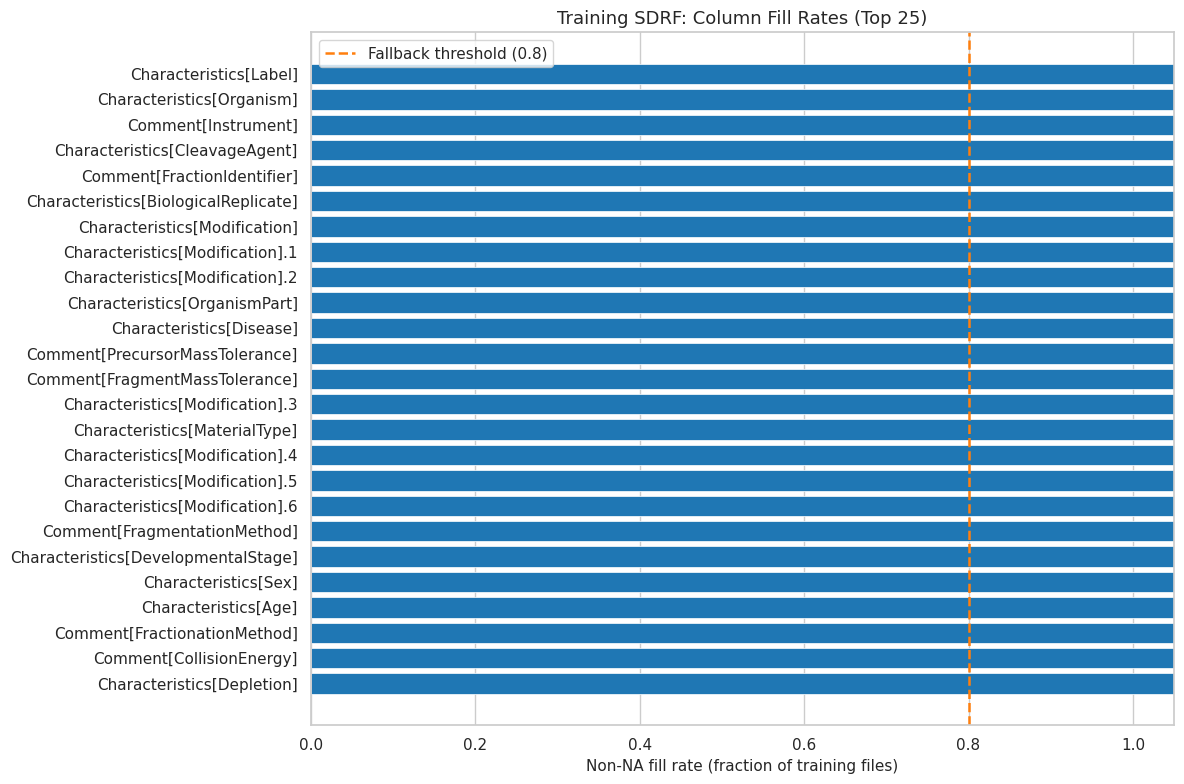

In [7]:
# ─────────────────────────────────────────────
# Visualization: Training SDRF column fill rates
# ─────────────────────────────────────────────
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({'figure.figsize': (10, 6), 'axes.titlesize': 13, 'axes.labelsize': 11})

fill_df = (
    pd.DataFrame({'column': list(non_na_ratio.keys()), 'fill_rate': list(non_na_ratio.values())})
    .sort_values('fill_rate', ascending=False)
    .head(25)
)

fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(
    fill_df['column'],
    fill_df['fill_rate'],
    color='#1f77b4',
    edgecolor='white',
    linewidth=0.5
)

ax.axvline(
    FALLBACK_RATIO,
    color='#ff7f0e',
    linestyle='--',
    linewidth=1.8,
    label=f'Fallback threshold ({FALLBACK_RATIO})'
)

ax.set_xlabel('Non-NA fill rate (fraction of training files)')
ax.set_title('Training SDRF: Column Fill Rates (Top 25)')
ax.set_xlim(0, 1.05)
ax.invert_yaxis()
ax.legend()

plt.tight_layout()
plt.show()

## 3. Data Cleaning

Defines text extraction helpers that isolate Methods-section content from publication JSON. Priority sections are matched against a whitelist of known section headings; remaining keys are filtered by methods-domain keywords. Text is concatenated and optionally truncated to `LLM_MAX_CHARS`.

In [8]:
# ─────────────────────────────────────────────
# Section whitelist: highest metadata density
# ─────────────────────────────────────────────

PRIORITY_SECTIONS = [
    'METHODS', 'MATERIALS AND METHODS', 'MATERIALS', 'EXPERIMENTAL',
    'SAMPLE PREPARATION', 'PROTEIN DIGESTION', 'MASS SPECTROMETRY',
    'LC-MS', 'LC-MS/MS', 'DATA ACQUISITION', 'DATA ANALYSIS', 'CELL CULTURE',
    'PROTEOMICS', 'PHOSPHOPROTEOMICS', 'PATIENTS', 'CLINICAL SAMPLES',
]

METHOD_KWS = [
    'method', 'material', 'protocol', 'procedure', 'digest',
    'spectr', 'chromat', 'lc', 'ms', 'prep', 'enrichment', 'culture',
    'patient', 'cohort', 'clinical', 'sample'
]


def get_text(pub_dict: dict, include_abstract: bool = True, max_chars: int = None) -> str:
    """Extract and concatenate prioritized section text from a publication JSON."""
    parts = []

    # Priority sections first
    for key in PRIORITY_SECTIONS:
        val = pub_dict.get(key, '')
        if isinstance(val, list):
            val = ' '.join(str(x) for x in val)
        if val.strip():
            parts.append(val.strip())

    # Secondary: any key matching methods keywords, not already captured
    for key, val in pub_dict.items():
        if key.upper() in PRIORITY_SECTIONS:
            continue
        if any(kw in key.lower() for kw in METHOD_KWS):
            if isinstance(val, list):
                val = ' '.join(str(x) for x in val)
            if val.strip():
                parts.append(val.strip())

    if include_abstract:
        for key in ['ABSTRACT', 'TITLE']:
            val = pub_dict.get(key, '')
            if isinstance(val, list):
                val = ' '.join(str(x) for x in val)
            if val.strip():
                parts.append(val.strip())

    text = ' '.join(parts)
    return text[:max_chars] if max_chars else text


def get_methods_text(pub_dict: dict, max_chars: int = LLM_MAX_CHARS) -> str:
    """Extract only priority sections and abstract for LLM input (cost-efficient)."""
    parts = []

    for key in PRIORITY_SECTIONS:
        val = pub_dict.get(key, '')
        if isinstance(val, list):
            val = ' '.join(str(x) for x in val)
        if val.strip():
            parts.append(val.strip())

    for key in ['ABSTRACT', 'TITLE']:
        val = pub_dict.get(key, '')
        if isinstance(val, list):
            val = ' '.join(str(x) for x in val)
        if val.strip():
            parts.append(val.strip())

    return ' '.join(parts)[:max_chars]


# [STATUS] Text extraction helpers defined  # [SUCCESS]

## 4. EDA

Analyses training SDRF vocabulary distributions across key metadata columns: organism, label, instrument, and organism part. Characterizes vocabulary depth per base column to identify data-sparse vs. data-rich fields.

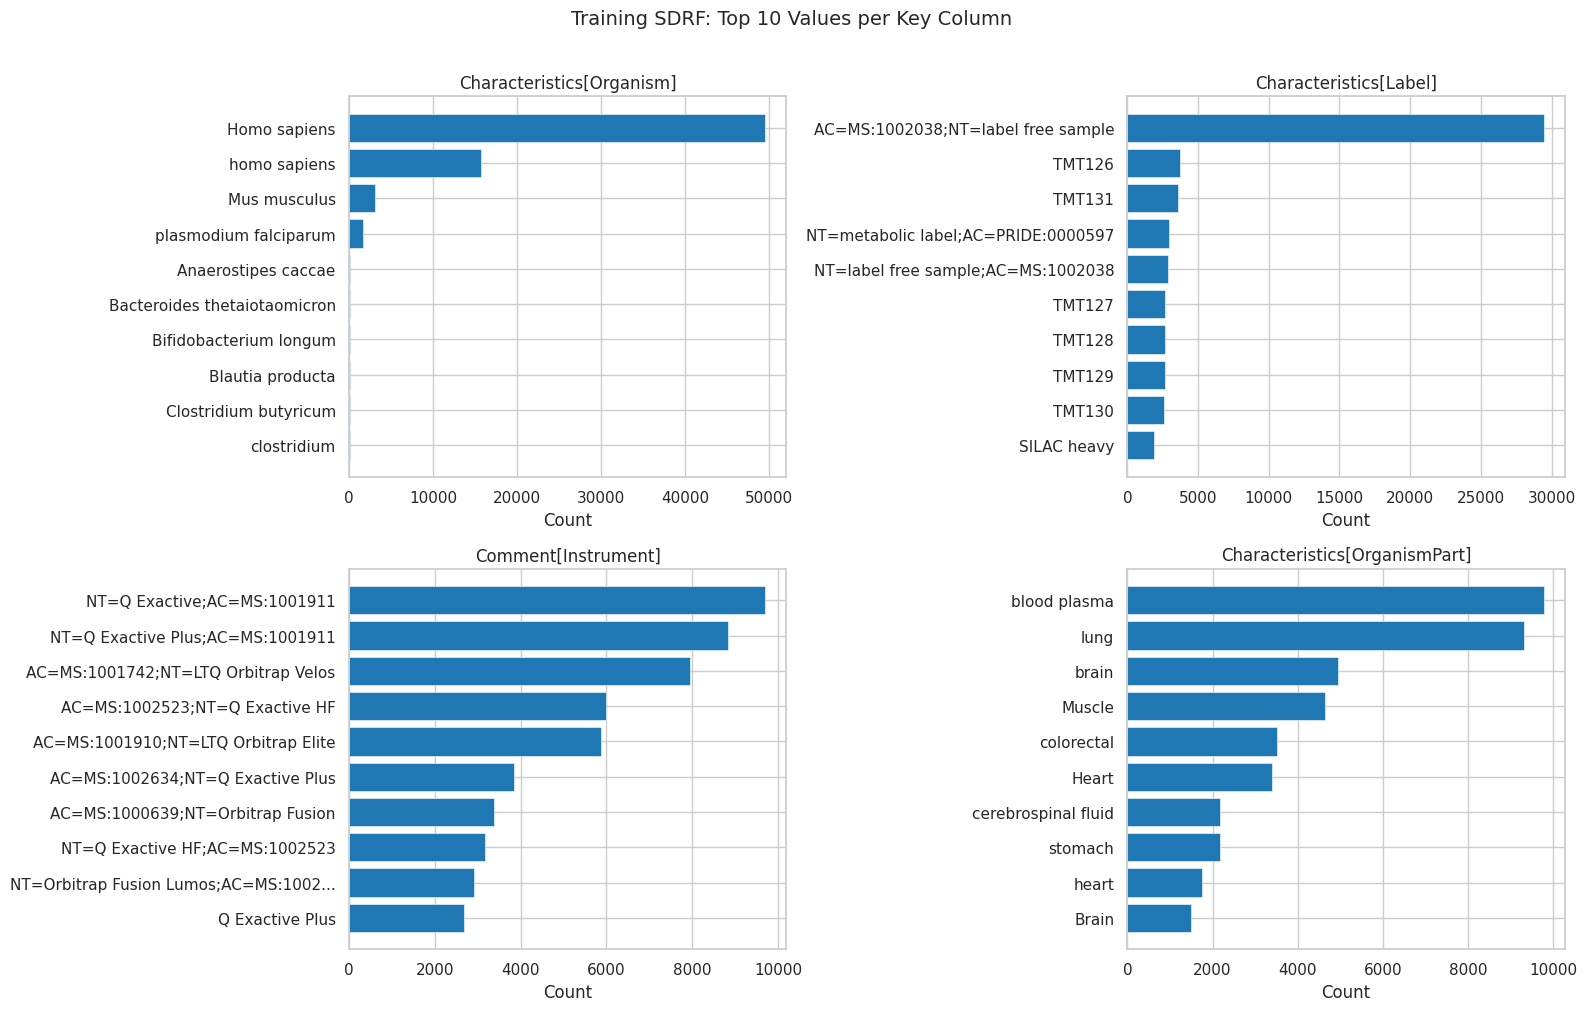

In [9]:
# ─────────────────────────────────────────────
# Visualization: Top values per key SDRF column
# ─────────────────────────────────────────────

sns.set_theme(style='whitegrid', context='notebook')

key_columns = [
    'Characteristics[Organism]',
    'Characteristics[Label]',
    'Comment[Instrument]',
    'Characteristics[OrganismPart]',
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, col in zip(axes, key_columns):
    bc = base_col(col)
    counter = col_counters.get(col, Counter())

    if counter:
        top = pd.DataFrame(counter.most_common(10), columns=['value', 'count'])
        # Truncate long ontology strings for readability
        top['label'] = top['value'].apply(lambda v: v[:35] + '...' if len(v) > 35 else v)
        ax.barh(top['label'], top['count'], color='#1f77b4', edgecolor='white', linewidth=0.4)
        ax.invert_yaxis()
        ax.set_xlabel('Count')
    else:
        ax.text(0.5, 0.5, 'No training data', ha='center', va='center', transform=ax.transAxes)

    ax.set_title(col)

plt.suptitle('Training SDRF: Top 10 Values per Key Column', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

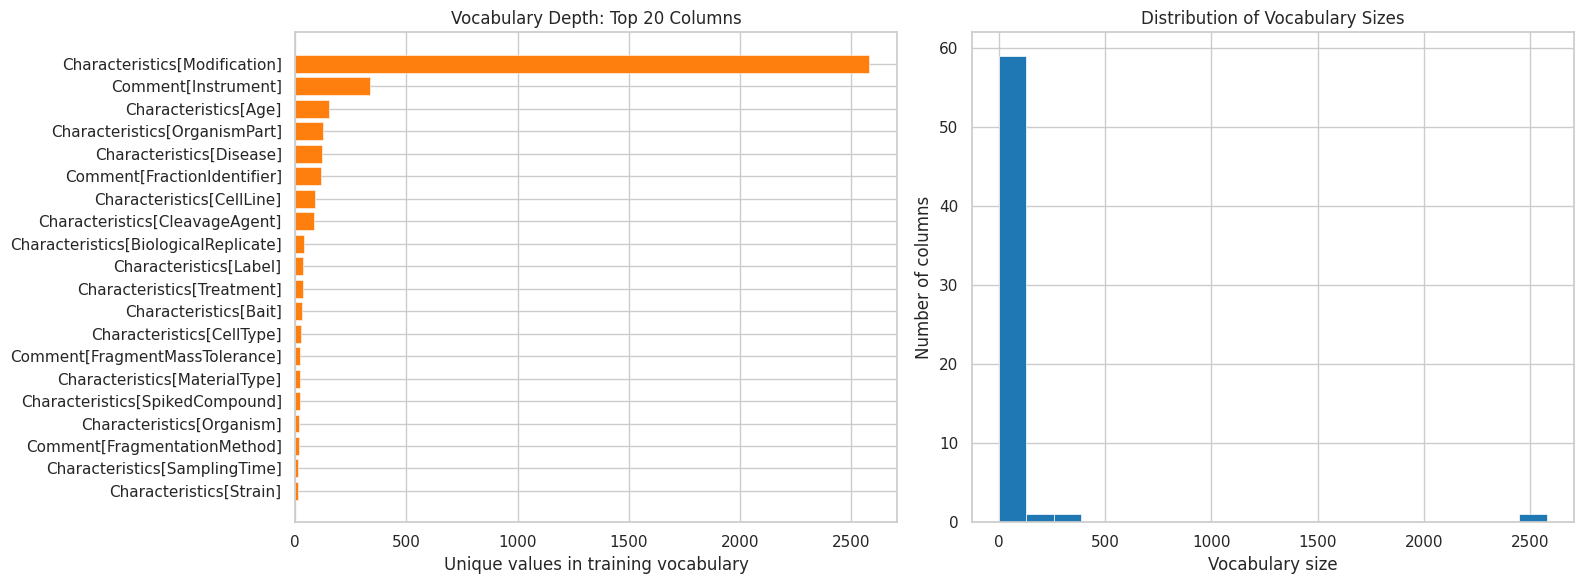

,vocab_size
count,62
mean,65
std,328
min,0
25%,0
50%,6
75%,20
max,2578


In [10]:
# ─────────────────────────────────────────────
# Visualization: Vocabulary size per base column
# ─────────────────────────────────────────────

vocab_sizes = (
    pd.DataFrame({
        'column':     list(col_vocab.keys()),
        'vocab_size': [len(v) for v in col_vocab.values()],
    })
    .sort_values('vocab_size', ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: top 20 columns by vocab size
top20 = vocab_sizes.head(20)
axes[0].barh(top20['column'], top20['vocab_size'], color='#ff7f0e', edgecolor='white', linewidth=0.4)
axes[0].invert_yaxis()
axes[0].set_xlabel('Unique values in training vocabulary')
axes[0].set_title('Vocabulary Depth: Top 20 Columns')

# Right: histogram of vocab sizes across all columns
axes[1].hist(vocab_sizes['vocab_size'], bins=20, color='#1f77b4', edgecolor='white', linewidth=0.5)
axes[1].set_xlabel('Vocabulary size')
axes[1].set_ylabel('Number of columns')
axes[1].set_title('Distribution of Vocabulary Sizes')

plt.tight_layout()
plt.show()

# Summary table
vocab_sizes.describe().astype(int)

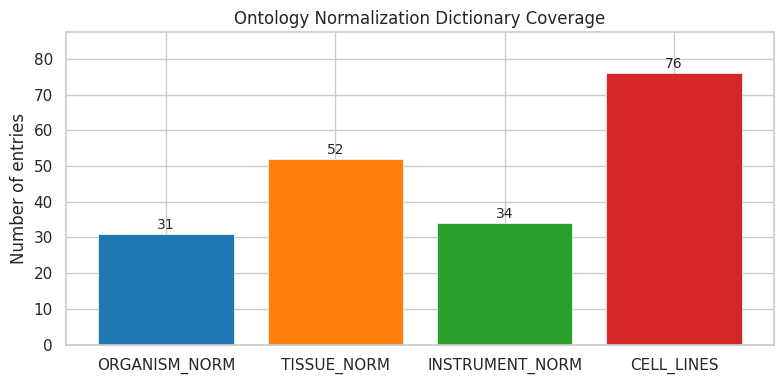

In [11]:
# ─────────────────────────────────────────────
# Visualization: Ontology dictionary coverage
# ─────────────────────────────────────────────

dict_coverage = pd.DataFrame([
    {'dictionary': 'ORGANISM_NORM',  'entries': len(ORGANISM_NORM),  'category': 'organisms'},
    {'dictionary': 'TISSUE_NORM',    'entries': len(TISSUE_NORM),    'category': 'tissues'},
    {'dictionary': 'INSTRUMENT_NORM','entries': len(INSTRUMENT_NORM),'category': 'instruments'},
    {'dictionary': 'CELL_LINES',     'entries': len(CELL_LINES),     'category': 'cell lines'},
])

fig, ax = plt.subplots(figsize=(8, 4))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
bars = ax.bar(
    dict_coverage['dictionary'],
    dict_coverage['entries'],
    color=colors,
    edgecolor='white',
    linewidth=0.5
)

for bar, val in zip(bars, dict_coverage['entries']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        str(val),
        ha='center', va='bottom', fontsize=10
    )

ax.set_ylabel('Number of entries')
ax.set_title('Ontology Normalization Dictionary Coverage')
ax.set_ylim(0, max(dict_coverage['entries']) * 1.15)

plt.tight_layout()
plt.show()

## 5. Feature Engineering

Implements four extraction modules: formatting and fuzzy-snap harmonization helpers, a rule-based regex engine covering all standard SDRF metadata fields, an LLM-based extraction module using the Anthropic API for semantic metadata inference, PRIDE/ProteomeXchange REST API fetchers, and a filename token parser for per-row fields.

In [12]:
# ─────────────────────────────────────────────
# Label quantification method formatter
# ─────────────────────────────────────────────

def fmt_label(n: str) -> str:
    """Map raw label string to MS ontology term."""
    n = str(n).lower().strip()

    if any(x in n for x in ['label free', 'label-free', 'lfq', 'label_free', 'unlab']):
        return 'AC=MS:1002038;NT=label free sample'

    if 'tmt' in n:
        m   = re.search(r'tmt[\s\-]?(\d+)', n)
        p   = m.group(1) if m else '6'
        acc = {'2': 'MS:1002456', '6': 'MS:1002453', '10': 'MS:1002454',
               '11': 'MS:1002454', '16': 'MS:1003998', '18': 'MS:1003999'}
        return f"AC={acc.get(p, 'MS:1002453')};NT=TMT{p}plex"

    if 'itraq' in n:
        m = re.search(r'itraq[\s\-]?(\d+)', n)
        p = m.group(1) if m else '4'
        return f"AC={'MS:1001985' if p == '4' else 'MS:1002519'};NT=iTRAQ{p}plex"

    if 'silac'   in n: return 'AC=MS:1002791;NT=SILAC'
    if 'dimethyl' in n: return 'AC=MS:1002457;NT=Dimethyl'

    return n


# ─────────────────────────────────────────────
# Instrument formatter
# ─────────────────────────────────────────────

def fmt_instrument(raw: str) -> str:
    """Map raw instrument string to MS ontology term via INSTRUMENT_NORM."""
    n = raw.lower().strip()
    for key, val in INSTRUMENT_NORM.items():
        if key in n:
            return val
    return raw


# ─────────────────────────────────────────────
# Fuzzy-snap: align extracted value to nearest training vocab entry
# ─────────────────────────────────────────────

# [UPDATED] - We route this directly to the hybrid semantic snap we built in Cell 3!
def fuzzy_snap(value: str, bc: str, cutoff: float = None) -> str:
    """
    Return the closest vocabulary match using Semantic/Lexical matching.
    """
    if not value or bc not in col_vocab:
        return value
        
    vocab_list = col_vocab[bc]
    if not vocab_list:
        return value
        
    # Passes extraction to our new consensus/hybrid matcher
    return semantic_snap(value, bc, vocab_list)

# [STATUS] fmt_label, fmt_instrument, fuzzy_snap defined  # [SUCCESS]

In [13]:
# ─────────────────────────────────────────────
# Negative lookbehind anchor for negated-context filtering
# ─────────────────────────────────────────────

_NEG = r"(?<!without\s)(?<!no\s)(?<!not\s)"

_CLINICAL = re.compile(
    r"\b(patient|cohort|biopsy|tumor|tumour|cancer|carcinoma|malignant|"
    r"diagnosed|clinical|disease|healthy\s+(?:control|donor)|specimen|"
    r"hospital|surgical|resection|serum|plasma|biopsy)\b", re.I)


def regex_extraction(pub_dict: dict) -> Dict[str, List[str]]:
    # Rule-based regex extraction of SDRF metadata from publication text.
    # Covers: organism, tissue, cell line/type, enzyme, label, modifications,
    # instrument, acquisition method, fractionation, enrichment, sex, disease,
    # tolerance parameters, replicate counts, gradient times, and more.
    text     = get_text(pub_dict)
    text_low = text.lower()
    extracted: Dict[str, List[str]] = {}

    def add(col, val):
        if val:
            extracted.setdefault(col, [])
            if val not in extracted[col]:
                extracted[col].append(val)

    # ── Organism ─────────────────────────────────────────────────────────────
    org_patterns = [
        (r"\b(homo\s+sapiens|human(?:s)?)\b",               "human"),
        (r"\b(mus\s+musculus|mouse|mice|murine)\b",          "mouse"),
        (r"\b(rattus\s+norvegicus|rat(?:s)?)\b",             "rat"),
        (r"\b(saccharomyces\s+cerevisiae|(?<!\w)yeast(?!\w))\b", "yeast"),
        (r"\b(escherichia\s+coli|e\.?\s*coli)\b",            "e. coli"),
        (r"\b(drosophila\s+melanogaster|fruit\s+fly)\b",     "fruit fly"),
        (r"\b(danio\s+rerio|zebrafish)\b",                   "zebrafish"),
        (r"\b(arabidopsis\s+thaliana)\b",                    "arabidopsis thaliana"),
        (r"\b(sus\s+scrofa|porcine|pig(?:s)?)\b",            "pig"),
        (r"\b(bos\s+taurus|bovine)\b",                       "bovine"),
        (r"\b(caenorhabditis\s+elegans|c\.\s*elegans)\b",    "c. elegans"),
        (r"\b(xenopus\s+laevis)\b",                          "xenopus laevis"),
        (r"\b(gallus\s+gallus|chicken)\b",                   "chicken"),
        (r"\b(canis\s+lupus\s+familiaris|dog(?:s)?)\b",      "dog"),
    ]
    for pat, key in org_patterns:
        if re.search(pat, text, re.I):
            add("Characteristics[Organism]", ORGANISM_NORM[key])

    # ── OrganismPart ──────────────────────────────────────────────────────────
    for tissue, norm in TISSUE_NORM.items():
        if re.search(r'\b' + re.escape(tissue) + r'\b', text_low):
            add("Characteristics[OrganismPart]", norm)

    # ── CellLine ──────────────────────────────────────────────────────────────
    for cl in CELL_LINES:
        if re.search(r'\b' + re.escape(cl) + r'\b', text, re.I):
            add("Characteristics[CellLine]", cl)

    # ── CellType ──────────────────────────────────────────────────────────────
    ct_patterns = [
        (r"\b(neurons?|neuronal\s+cells?)\b",                  "neurons"),
        (r"\b(astrocytes?)\b",                                  "astrocytes"),
        (r"\b(microglia)\b",                                    "microglia"),
        (r"\b(macrophages?)\b",                                 "macrophages"),
        (r"\b(dendritic\s+cells?)\b",                          "dendritic cells"),
        (r"\b(fibroblasts?)\b",                                 "fibroblasts"),
        (r"\b(t[\s\-]cells?|cd4\+|cd8\+)\b",                  "T cells"),
        (r"\b(b[\s\-]cells?)\b",                               "B cells"),
        (r"\b(monocytes?)\b",                                   "monocytes"),
        (r"\b(nk\s+cells?|natural\s+killer)\b",                "NK cells"),
        (r"\b(pbmc|peripheral\s+blood\s+mononuclear)\b",       "PBMC"),
        (r"\b(hepatocytes?)\b",                                 "hepatocytes"),
        (r"\b(cardiomyocytes?)\b",                             "cardiomyocytes"),
        (r"\b(adipocytes?)\b",                                  "adipocytes"),
        (r"\b(osteoblasts?)\b",                                 "osteoblasts"),
        (r"\b(platelets?|thrombocytes?)\b",                    "platelets"),
        (r"\b(erythrocytes?|red\s+blood\s+cells?)\b",          "erythrocytes"),
        (r"\b(stem\s+cells?)\b",                               "stem cells"),
        (r"\b(myotubes?)\b",                                    "myotubes"),
    ]
    for pat, val in ct_patterns:
        if re.search(pat, text, re.I):
            add("Characteristics[CellType]", val)

    # ── CleavageAgent ─────────────────────────────────────────────────────────
    for pat, val in [
        (re.compile(_NEG + r"\b(trypsin(?:/lys[\s\-]?c)?)\b",  re.I), "AC=MS:1001251;NT=Trypsin"),
        (re.compile(_NEG + r"\b(lys[\s\-]?c)\b",               re.I), "AC=MS:1001255;NT=Lys-C"),
        (re.compile(_NEG + r"\b(glu[\s\-]?c)\b",               re.I), "AC=MS:1001917;NT=Glu-C"),
        (re.compile(_NEG + r"\b(chymotrypsin)\b",               re.I), "AC=MS:1001306;NT=Chymotrypsin"),
        (re.compile(_NEG + r"\b(asp[\s\-]?n)\b",               re.I), "AC=MS:1001267;NT=Asp-N"),
        (re.compile(_NEG + r"\b(arg[\s\-]?c)\b",               re.I), "AC=MS:1001303;NT=Arg-C"),
        (re.compile(_NEG + r"\b(cnbr|cyanogen\s+bromide)\b",   re.I), "AC=MS:1001325;NT=CNBr"),
        (re.compile(_NEG + r"\b(elastase)\b",                   re.I), "AC=MS:1001307;NT=Elastase"),
        (re.compile(_NEG + r"\b(thermolysin)\b",                re.I), "AC=MS:1001963;NT=Thermolysin"),
    ]:
        if pat.search(text):
            add("Characteristics[CleavageAgent]", val)
            break

    # ── Label ─────────────────────────────────────────────────────────────────
    label_patterns = [
        (re.compile(r"\b(tmt[\s\-]?(?:10|11|16|18|2|6)?(?:plex)?)\b", re.I),
         lambda m: fmt_label(m.group(1))),
        (re.compile(r"\b(itraq[\s\-]?(?:4|8)?(?:plex)?)\b", re.I),
         lambda m: fmt_label(m.group(1))),
        (re.compile(r"\b(silac)\b", re.I),
         lambda m: "AC=MS:1002791;NT=SILAC"),
        (re.compile(r"\b(label[\s\-]free|lfq)\b", re.I),
         lambda m: "AC=MS:1002038;NT=label free sample"),
        (re.compile(r"\b(dimethyl\s+label(?:ing)?|reductive\s+dimethylation)\b", re.I),
         lambda m: "AC=MS:1002457;NT=Dimethyl"),
        (re.compile(r"\b(tandem\s+mass\s+tag)\b", re.I),
         lambda m: "AC=MS:1002453;NT=TMT6plex"),
    ]
    for pat, fn in label_patterns:
        m = pat.search(text)
        if m:
            add("Characteristics[Label]", fn(m))
            break

    # ── ReductionReagent ──────────────────────────────────────────────────────
    for pat, val in [
        (re.compile(_NEG + r"\b(dtt|dithiothreitol)\b",                       re.I), "AC=MS:1000578;NT=DTT"),
        (re.compile(_NEG + r"\b(tcep)\b",                                      re.I), "AC=MS:1001135;NT=TCEP"),
        (re.compile(_NEG + r"\b(beta[\s\-]?mercaptoethanol|bme)\b",            re.I), "AC=MS:1000382;NT=beta-mercaptoethanol"),
        (re.compile(_NEG + r"\b(tris\(2\-carboxyethyl\)phosphine)\b",          re.I), "AC=MS:1001135;NT=TCEP"),
    ]:
        if pat.search(text):
            add("Characteristics[ReductionReagent]", val)
            break

    # ── AlkylationReagent ─────────────────────────────────────────────────────
    for pat, val in [
        (re.compile(r"\b(iodoacetamide|iaa)\b",           re.I), "AC=PRIDE:0000126;NT=Iodoacetamide"),
        (re.compile(r"\b(n[\s\-]?ethylmaleimide|nem)\b",  re.I), "AC=PRIDE:0000459;NT=N-ethylmaleimide"),
        (re.compile(r"\b(chloroacetamide|caa)\b",         re.I), "AC=PRIDE:0000126;NT=Chloroacetamide"),
        (re.compile(r"\b(4[\s\-]?vinylpyridine)\b",       re.I), "AC=PRIDE:0000101;NT=4-vinylpyridine"),
    ]:
        if pat.search(text):
            add("Characteristics[AlkylationReagent]", val)
            break

    # ── Modifications (collect all; capped later) ─────────────────────────────
    mod_patterns = [
        (re.compile(r"\b(carbamidomethyl(?:ation)?|iodoacetamide)\b", re.I),
         "NT=Carbamidomethyl;AC=UNIMOD:4;TA=C;MT=Fixed"),
        (re.compile(r"\b(oxidation(?:\s+of\s+methionine)?)\b", re.I),
         "NT=Oxidation;AC=UNIMOD:35;TA=M;MT=Variable"),
        (re.compile(r"\b(phospho(?:rylation)?)\b", re.I),
         "NT=Phospho;AC=UNIMOD:21;TA=S,T,Y;MT=Variable"),
        (re.compile(r"\b(acetyl(?:ation)?(?:\s+of\s+(?:lysine|n.?term))?)\b", re.I),
         "NT=Acetyl;AC=UNIMOD:1;TA=K;MT=Variable"),
        (re.compile(r"\b(ubiquitin(?:ation)?|di[\s\-]?glycine|gg[\s\-]?remnant)\b", re.I),
         "NT=GlyGly;AC=UNIMOD:121;TA=K;MT=Variable"),
        (re.compile(r"\b(methylation(?:\s+of\s+(?:lysine|arginine))?)\b", re.I),
         "NT=Methyl;AC=UNIMOD:34;TA=K,R;MT=Variable"),
        (re.compile(r"\b(sumoylation)\b", re.I),
         "NT=SUMO;AC=UNIMOD:3;TA=K;MT=Variable"),
        (re.compile(r"\b(deamidation(?:\s+of\s+(?:asparagine|glutamine))?)\b", re.I),
         "NT=Deamidated;AC=UNIMOD:7;TA=N,Q;MT=Variable"),
        (re.compile(r"\b(s-nitrosylation|nitrosylation)\b", re.I),
         "NT=Nitrosyl;AC=UNIMOD:275;TA=C;MT=Variable"),
        (re.compile(r"\b(crotonylation)\b", re.I),
         "NT=Crotonyl;AC=UNIMOD:1363;TA=K;MT=Variable"),
        (re.compile(r"\b(succinylation)\b", re.I),
         "NT=Succinyl;AC=UNIMOD:64;TA=K;MT=Variable"),
        (re.compile(r"\b(malonylation)\b", re.I),
         "NT=Malonyl;AC=UNIMOD:747;TA=K;MT=Variable"),
        (re.compile(r"\b(palmitoylation)\b", re.I),
         "NT=Palmitoyl;AC=UNIMOD:47;TA=C,K,S;MT=Variable"),
        (re.compile(r"\b(n[\s\-]?terminal\s+acetyl(?:ation)?)\b", re.I),
         "NT=Acetyl;AC=UNIMOD:1;TA=N-term;MT=Variable"),
    ]
    for pat, val in mod_patterns:
        if pat.search(text):
            add("Characteristics[Modification]", val)

    # ── AcquisitionMethod ─────────────────────────────────────────────────────
    for pat, val in [
        (re.compile(r"\b(dda|data[\s\-]dependent\s+acquisition)\b",  re.I), "AC=MS:1003215;NT=DDA"),
        (re.compile(r"\b(dia|data[\s\-]independent\s+acquisition|swath)\b", re.I), "AC=MS:1003215;NT=DIA"),
        (re.compile(r"\b(prm|parallel\s+reaction\s+monitoring)\b",    re.I), "AC=MS:1001501;NT=PRM"),
        (re.compile(r"\b(srm|mrm|selected\s+reaction\s+monitoring)\b",re.I), "AC=MS:1001501;NT=SRM"),
        (re.compile(r"\b(boxcar)\b",                                   re.I), "AC=MS:1003215;NT=DDA"),
    ]:
        if pat.search(text):
            add("Comment[AcquisitionMethod]", val)
            break

    # ── Instrument ────────────────────────────────────────────────────────────
    inst_patterns = [
        r"\b(Q[\s\-]?Exactive[\s\-]?HF[\s\-]?X)\b",
        r"\b(Orbitrap\s+Astral)\b",
        r"\b(Orbitrap\s+Exploris\s+480|Exploris\s+480)\b",
        r"\b(Orbitrap\s+Exploris\s+240|Exploris\s+240)\b",
        r"\b(Q[\s\-]?Exactive[\s\-]?HF)\b",
        r"\b(Q[\s\-]?Exactive[\s\-]?Plus)\b",
        r"\b(Q[\s\-]?Exactive)\b",
        r"\b(Orbitrap\s+Fusion\s+Lumos)\b",
        r"\b(Orbitrap\s+Fusion)\b",
        r"\b(Orbitrap\s+Eclipse)\b",
        r"\b(LTQ[\s\-]?Orbitrap\s+Velos)\b",
        r"\b(LTQ[\s\-]?Orbitrap\s+Elite)\b",
        r"\b(LTQ[\s\-]?Orbitrap\s+XL)\b",
        r"\b(LTQ[\s\-]?Orbitrap)\b",
        r"\b(timsTOF\s+Pro\s+2)\b",
        r"\b(timsTOF\s+Pro)\b",
        r"\b(timsTOF\s+SCP)\b",
        r"\b(timsTOF)\b",
        r"\b(Triple[\s\-]?TOF\s+6600)\b",
        r"\b(Triple[\s\-]?TOF\s+5600)\b",
        r"\b(Triple[\s\-]?TOF)\b",
        r"\b(Impact\s+II)\b",
        r"\b(maXis\s+Speed)\b",
        r"\b(Synapt\s+G2)\b",
    ]
    for pat in inst_patterns:
        m = re.search(pat, text, re.I)
        if m:
            add("Comment[Instrument]", fmt_instrument(m.group(1)))
            break

    # ── FragmentationMethod ───────────────────────────────────────────────────
    for pat, val in [
        (re.compile(r"\b(hcd)\b", re.I), "AC=MS:1002481;NT=HCD"),
        (re.compile(r"\b(cid)\b", re.I), "AC=MS:1001880;NT=CID"),
        (re.compile(r"\b(etd)\b", re.I), "AC=MS:1001526;NT=ETD"),
        (re.compile(r"\b(ecd)\b", re.I), "AC=MS:1001872;NT=ECD"),
        (re.compile(r"\b(uvpd)\b", re.I), "AC=MS:1003246;NT=UVPD"),
    ]:
        if pat.search(text):
            add("Comment[FragmentationMethod]", val)

    # ── IonizationType ────────────────────────────────────────────────────────
    for pat, val in [
        (re.compile(r"\b(nano[\s\-]?esi|nesi)\b",             re.I), "AC=MS:1000398;NT=nanoESI"),
        (re.compile(r"\b(electrospray|(?<!\bnano)esi)\b",      re.I), "AC=MS:1000073;NT=ESI"),
        (re.compile(r"\b(maldi)\b",                            re.I), "AC=MS:1000075;NT=MALDI"),
        (re.compile(r"\b(apci)\b",                             re.I), "AC=MS:1000070;NT=APCI"),
    ]:
        if pat.search(text):
            add("Comment[IonizationType]", val)
            break

    # ── MS2MassAnalyzer ───────────────────────────────────────────────────────
    for pat, val in [
        (re.compile(r"\b(orbitrap)\b",    re.I), "AC=MS:1000484;NT=Orbitrap"),
        (re.compile(r"\b(ion\s*trap)\b",  re.I), "AC=MS:1000264;NT=ion trap"),
        (re.compile(r"\b(tof)\b",         re.I), "AC=MS:1000084;NT=TOF"),
        (re.compile(r"\b(quadrupole)\b",  re.I), "AC=MS:1000081;NT=Quadrupole"),
    ]:
        if pat.search(text):
            add("Comment[MS2MassAnalyzer]", val)
            break

    # ── FractionationMethod ───────────────────────────────────────────────────
    for pat, val in [
        (re.compile(r"\b(sds[\s\-]?page)\b",                                    re.I), "AC=PRIDE:0000672;NT=SDS-PAGE"),
        (re.compile(r"\b(scx|strong\s+cation\s+exchange)\b",                    re.I), "AC=PRIDE:0000228;NT=SCX"),
        (re.compile(r"\b(sax|strong\s+anion\s+exchange)\b",                     re.I), "AC=PRIDE:0000229;NT=SAX"),
        (re.compile(r"\b(hprp|high[\s\-]ph\s+rp|high[\s\-]ph\s+reversed[\s\-]phase)\b", re.I),
         "AC=PRIDE:0000550;NT=High-pH Reversed-Phase"),
        (re.compile(r"\b(isoelectric\s+focusing|ief)\b",                        re.I), "AC=PRIDE:0000006;NT=IEF"),
        (re.compile(r"\b(size[\s\-]exclusion\s+chromatography|sec[\s\-]hplc)\b",re.I), "AC=PRIDE:0000020;NT=SEC"),
        (re.compile(r"\b(offgel)\b",                                             re.I), "AC=PRIDE:0000006;NT=Off-gel IEF"),
        (re.compile(r"\b(basic\s+rp|bRP)\b",                                    re.I), "AC=PRIDE:0000550;NT=High-pH Reversed-Phase"),
    ]:
        if pat.search(text):
            add("Comment[FractionationMethod]", val)
            break

    # ── EnrichmentMethod ──────────────────────────────────────────────────────
    for pat, val in [
        (re.compile(r"\b(tio2?|titanium\s+dioxide)\b",                          re.I), "AC=MS:1002088;NT=TiO2"),
        (re.compile(r"\b(imac|immobilized\s+metal\s+affinity)\b",               re.I), "AC=MS:1001923;NT=IMAC"),
        (re.compile(r"\b(immunoaffinity|immunoprecipitation|ip[\s\-]ms)\b",     re.I), "AC=MS:1002090;NT=Immunoprecipitation"),
        (re.compile(r"\b(glycopeptide\s+enrichment|lectin)\b",                  re.I), "Glycopeptide enrichment"),
        (re.compile(r"\b(streptavidin|avidin[\s\-]biotin)\b",                   re.I), "Streptavidin affinity"),
        (re.compile(r"\b(fe3o4|magnetic\s+beads)\b",                            re.I), "AC=MS:1002088;NT=TiO2"),
    ]:
        if pat.search(text):
            add("Comment[EnrichmentMethod]", val)
            break

    # ── Separation ────────────────────────────────────────────────────────────
    for pat, val in [
        (re.compile(r"\b(nano[\s\-]?lc)\b",                          re.I), "AC=PRIDE:0000565;NT=nanoLC"),
        (re.compile(r"\b(uplc|uhplc)\b",                              re.I), "UPLC"),
        (re.compile(r"\b(rplc|reversed[\s\-]phase\s+lc)\b",          re.I), "AC=PRIDE:0000550;NT=Reversed-Phase"),
        (re.compile(r"\b(c18\s+column)\b",                            re.I), "AC=PRIDE:0000550;NT=Reversed-Phase"),
        (re.compile(r"\b(easy[\s\-]nlc|easy\s+nano)\b",              re.I), "AC=PRIDE:0000565;NT=nanoLC"),
    ]:
        if pat.search(text):
            add("Comment[Separation]", val)
            break

    # ── Sex ───────────────────────────────────────────────────────────────────
    if re.search(r"\b(male\s+and\s+female|both\s+sexes|mixed\s+sex|male/female)\b", text, re.I):
        add("Characteristics[Sex]", "male and female")
    elif re.search(r"\b(male\s+(?:donors?|subjects?|patients?|volunteers?|mice|rats?)|(?:^|\s)men\b|male\s+samples?)\b", text, re.I):
        add("Characteristics[Sex]", "male")
    elif re.search(r"\b(female\s+(?:donors?|subjects?|patients?|volunteers?|mice|rats?)|(?:^|\s)women\b|female\s+samples?)\b", text, re.I):
        add("Characteristics[Sex]", "female")

    # ── Disease (only when clinical context is present) ───────────────────────
    if _CLINICAL.search(text):
        disease_patterns = [
            (r"\b(alzheimer[\s']?s?\s+disease)\b",                   "Alzheimer disease"),
            (r"\b(parkinson[\s']?s?\s+disease)\b",                   "Parkinson disease"),
            (r"\b(type\s+2\s+diabetes|t2d(?:m)?)\b",                "type 2 diabetes mellitus"),
            (r"\b(type\s+1\s+diabetes|t1d(?:m)?)\b",                "type 1 diabetes mellitus"),
            (r"\b(breast\s+(?:cancer|carcinoma))\b",                 "breast carcinoma"),
            (r"\b(colorectal\s+(?:cancer|carcinoma)|colon\s+cancer)\b", "colorectal carcinoma"),
            (r"\b(lung\s+(?:cancer|carcinoma))\b",                   "lung carcinoma"),
            (r"\b(glioblastoma|gbm)\b",                              "glioblastoma"),
            (r"\b(melanoma)\b",                                       "melanoma"),
            (r"\b(prostate\s+(?:cancer|carcinoma))\b",               "prostate carcinoma"),
            (r"\b(ovarian\s+(?:cancer|carcinoma))\b",                "ovarian carcinoma"),
            (r"\b(hepatocellular\s+carcinoma|hcc)\b",                "hepatocellular carcinoma"),
            (r"\b(pancreatic\s+(?:cancer|carcinoma|ductal\s+adenocarcinoma)|pdac)\b",
             "pancreatic ductal adenocarcinoma"),
            (r"\b(covid[\s\-]?19|sars[\s\-]?cov[\s\-]?2)\b",        "COVID-19"),
            (r"\b(multiple\s+myeloma)\b",                             "multiple myeloma"),
            (r"\b(acute\s+myeloid\s+leukemia|aml)\b",                "acute myeloid leukemia"),
            (r"\b(non[\s\-]small[\s\-]cell\s+lung|nsclc)\b",         "non-small cell lung carcinoma"),
            (r"\b(triple[\s\-]negative\s+breast|tnbc)\b",            "triple-negative breast carcinoma"),
            (r"\b(healthy\s+(?:controls?|donors?|volunteers?|individuals?))\b", "normal"),
            (r"\b(amyotrophic\s+lateral\s+sclerosis|als)\b",         "amyotrophic lateral sclerosis"),
            (r"\b(huntington[\s']?s?\s+disease)\b",                  "Huntington disease"),
            (r"\b(autism\s+spectrum\s+disorder|asd)\b",              "autism spectrum disorder"),
            (r"\b(schizophrenia)\b",                                  "schizophrenia"),
            (r"\b(rheumatoid\s+arthritis)\b",                         "rheumatoid arthritis"),
            (r"\b(sepsis)\b",                                         "sepsis"),
        ]
        for pat, val in disease_patterns:
            if re.search(pat, text, re.I):
                add("Characteristics[Disease]", val)

    # ── MaterialType ──────────────────────────────────────────────────────────
    if "Characteristics[CellLine]" in extracted:
        add("Characteristics[MaterialType]", "cell line")
    elif "Characteristics[CellType]" in extracted:
        add("Characteristics[MaterialType]", "primary cells")
    elif re.search(r"\b(tissue(?:s)?(?!\s+culture)|biopsy|biopsies|tumor|tumour)\b", text, re.I):
        add("Characteristics[MaterialType]", "tissue")
    elif re.search(r"\b(plasma|serum|urine|csf|saliva|blood)\b", text, re.I):
        add("Characteristics[MaterialType]", "biofluid")
    elif re.search(r"\b(organoid)\b", text, re.I):
        add("Characteristics[MaterialType]", "organoid")
    elif re.search(r"\b(exosome|extracellular\s+vesicle|ev)\b", text, re.I):
        add("Characteristics[MaterialType]", "extracellular vesicle")

    # ── Specimen ──────────────────────────────────────────────────────────────
    for pat, val in [
        (re.compile(r"\b(ffpe|formalin[\s\-]fixed)\b",    re.I), "FFPE"),
        (re.compile(r"\b(fresh[\s\-]frozen)\b",            re.I), "fresh frozen tissue"),
        (re.compile(r"\b(whole\s+blood)\b",                re.I), "whole blood"),
        (re.compile(r"\b(cell\s+lysate(?:s)?)\b",          re.I), "cell lysate"),
        (re.compile(r"\b(biopsy|biopsies)\b",              re.I), "biopsy"),
        (re.compile(r"\b(urine)\b",                        re.I), "urine"),
        (re.compile(r"\b(serum)\b",                        re.I), "serum"),
        (re.compile(r"\b(plasma)\b",                       re.I), "plasma"),
    ]:
        if pat.search(text):
            add("Characteristics[Specimen]", val)
            break

    # ── Strain ────────────────────────────────────────────────────────────────
    for pat, val in [
        (re.compile(r"\b(C57BL/6J?)\b"),               "C57BL/6J"),
        (re.compile(r"\b(BALB/c)\b"),                   "BALB/c"),
        (re.compile(r"\b(FVB/N)\b"),                    "FVB/N"),
        (re.compile(r"\b(129/Sv(?:ev)?)\b", re.I),     "129/SvEv"),
        (re.compile(r"\b(Sprague[\s\-]Dawley)\b", re.I), "Sprague-Dawley"),
        (re.compile(r"\b(Wistar)\b", re.I),             "Wistar"),
        (re.compile(r"\b(nude\s+mice?|athymic\s+nude)\b", re.I), "nude"),
        (re.compile(r"\b(NOD/SCID)\b", re.I),           "NOD/SCID"),
        (re.compile(r"\b(ob/ob)\b", re.I),               "ob/ob"),
        (re.compile(r"\b(db/db)\b", re.I),               "db/db"),
        (re.compile(r"\b(DBA/2)\b", re.I),               "DBA/2"),
        (re.compile(r"\b(CBA/J)\b", re.I),               "CBA/J"),
    ]:
        m = pat.search(text)
        if m:
            add("Characteristics[Strain]", val)
            break

    # ── Genotype ──────────────────────────────────────────────────────────────
    for pat, val in [
        (re.compile(r"\b(wild[\s\-]?type|wt(?:\s+cells?|\s+mice)?)\b", re.I), "wild-type"),
        (re.compile(r"\b(knockout|knock[\s\-]out|ko(?:\s+cells?|\s+mice)?)\b", re.I), "knockout"),
        (re.compile(r"\b(knock[\s\-]?in)\b",  re.I), "knock-in"),
        (re.compile(r"\b(transgenic)\b",       re.I), "transgenic"),
        (re.compile(r"\b(heterozygous)\b",     re.I), "heterozygous"),
        (re.compile(r"\b(homozygous)\b",       re.I), "homozygous"),
    ]:
        if pat.search(text):
            add("Characteristics[Genotype]", val)
            break

    # ── DevelopmentalStage ────────────────────────────────────────────────────
    for pat, val in [
        (re.compile(r"\b(adult(?:s)?)\b",                                         re.I), "adult"),
        (re.compile(r"\b(embryo(?:nic)?|E\d{1,2}\.?\d?)\b",                      re.I), "embryo"),
        (re.compile(r"\b(fetal|fetus|foetal)\b",                                  re.I), "fetal"),
        (re.compile(r"\b(neonatal|newborn|postnatal\s+day\s+[0-5])\b",           re.I), "neonatal"),
        (re.compile(r"\b(juvenile|adolescent)\b",                                 re.I), "juvenile"),
    ]:
        if pat.search(text):
            add("Characteristics[DevelopmentalStage]", val)
            break

    # ── GradientTime ──────────────────────────────────────────────────────────
    for pat in [
        re.compile(r"(\d+)[\s\-]min(?:ute)?\s+(?:gradient|lc[\s\-]?ms?|linear\s+gradient|run)", re.I),
        re.compile(r"gradient\s+(?:of\s+)?(\d+)[\s\-]?min",                    re.I),
        re.compile(r"(\d+)[\s\-]min(?:ute)?\s+(?:separation|elution)",         re.I),
        re.compile(r"over\s+(\d+)\s+min(?:utes?)?",                             re.I),
    ]:
        m = pat.search(text)
        if m:
            add("Comment[GradientTime]", f"{m.group(1)} min")
            break

    # ── FlowRateChromatogram ──────────────────────────────────────────────────
    m = re.search(r"(\d+(?:\.\d+)?)\s*(nl|nL|ul|uL|µl|µL)/min", text, re.I)
    if m:
        unit = "nL" if m.group(2).lower() == "nl" else "µL"
        add("Comment[FlowRateChromatogram]", f"{m.group(1)} {unit}/min")

    # ── PrecursorMassTolerance ────────────────────────────────────────────────
    for pat in [
        re.compile(r"(?:precursor|ms1|parent)\s+(?:mass\s+)?tolerance(?:\s+of)?\s+(\d+(?:\.\d+)?)\s*(ppm|da)", re.I),
        re.compile(r"(\d+(?:\.\d+)?)\s*ppm\s+(?:precursor|ms1|parent|for\s+ms1)",  re.I),
        re.compile(r"ms1\s+(?:mass\s+)?accuracy\s+of\s+(\d+(?:\.\d+)?)\s*(ppm)",   re.I),
    ]:
        m = pat.search(text)
        if m:
            unit = m.group(2) if m.lastindex and m.lastindex >= 2 else "ppm"
            add("Comment[PrecursorMassTolerance]", f"{m.group(1)} {unit}")
            break

    # ── FragmentMassTolerance ─────────────────────────────────────────────────
    for pat in [
        re.compile(r"(?:fragment|ms2|product)\s+(?:mass\s+)?tolerance(?:\s+of)?\s+(\d+(?:\.\d+)?)\s*(ppm|da|mda)", re.I),
        re.compile(r"(\d+(?:\.\d+)?)\s*(da|mda)\s+(?:for\s+)?(?:fragment|ms2|product)", re.I),
        re.compile(r"ms2\s+(?:mass\s+)?accuracy\s+of\s+(\d+(?:\.\d+)?)\s*(da|ppm)",     re.I),
    ]:
        m = pat.search(text)
        if m:
            unit = m.group(2) if m.lastindex and m.lastindex >= 2 else "Da"
            add("Comment[FragmentMassTolerance]", f"{m.group(1)} {unit}")
            break

    # ── NumberOfMissedCleavages ───────────────────────────────────────────────
    for pat in [
        re.compile(r"(?:up\s+to\s+|allowing\s+(?:up\s+to\s+)?)(\d)\s+missed\s+cleavages?",  re.I),
        re.compile(r"(\d)\s+missed\s+cleavages?\s+(?:were\s+)?allowed",                      re.I),
        re.compile(r"missed\s+cleavages?\s*[=:]\s*(\d)",                                     re.I),
        re.compile(r"maximum\s+(?:of\s+)?(\d)\s+missed\s+cleavages?",                       re.I),
    ]:
        m = pat.search(text)
        if m:
            add("Comment[NumberOfMissedCleavages]", m.group(1))
            break

    # ── NumberOfBiologicalReplicates ──────────────────────────────────────────
    for pat in [
        re.compile(r"(\d+)\s+(?:independent\s+)?biological\s+replicates?",                   re.I),
        re.compile(r"biological\s+replicates?\s+\(n\s*[=≥]\s*(\d+)\)",                      re.I),
        re.compile(r"n\s*=\s*(\d+)\s+(?:independent\s+)?(?:biological\s+)?replicates?",     re.I),
        re.compile(r"performed\s+in\s+(triplicate|duplicate|quadruplicate)",                  re.I),
        re.compile(r"(?:biological\s+)?triplicates?\b",                                       re.I),
    ]:
        m = pat.search(text)
        if m:
            wmap = {'triplicate': '3', 'duplicate': '2', 'quadruplicate': '4'}
            val  = (wmap.get(m.group(1).lower(), m.group(1)) if m.lastindex else '3')
            add("Characteristics[NumberOfBiologicalReplicates]", val)
            break

    # ── NumberOfSamples ───────────────────────────────────────────────────────
    for pat in [
        re.compile(r"(\d+)\s+(?:clinical\s+)?(?:patient|tumor|tissue|plasma|serum|urine)\s+samples?", re.I),
        re.compile(r"cohort\s+of\s+(\d+)\s+(?:patients?|subjects?|individuals?|participants?)",        re.I),
        re.compile(r"(\d+)\s+(?:patients?|subjects?|individuals?|participants?)\s+(?:were|with|diagnosed)", re.I),
        re.compile(r"total\s+of\s+(\d+)\s+samples?",                                                  re.I),
    ]:
        m = pat.search(text)
        if m:
            add("Characteristics[NumberOfSamples]", m.group(1))
            break

    # ── NumberOfFractions ─────────────────────────────────────────────────────
    for pat in [
        re.compile(r"(?:fractionated\s+into|collected\s+into|divided\s+into)\s+(\d+)\s+fractions?", re.I),
        re.compile(r"(\d+)\s+(?:scx|hprp|rp|sds[\s\-]?page|gel)?\s*fractions?\s+(?:were|of)",      re.I),
        re.compile(r"(\d+)[\s\-]fraction\s+(?:separation|fractionation)",                           re.I),
    ]:
        m = pat.search(text)
        if m:
            add("Comment[NumberOfFractions]", m.group(1))
            break

    # ── TumorStage / TumorGrade ───────────────────────────────────────────────
    m = re.search(r"\b(?:ajcc\s+)?(?:clinical\s+)?stage\s+([IViv]+)\b", text, re.I)
    if m:
        add("Characteristics[TumorStage]", f"Stage {m.group(1).upper()}")

    for pat in [
        re.compile(r"\bgrade\s+([IViv\d]+)\b",                  re.I),
        re.compile(r"\bgleason\s+(?:score\s+)?(\d+)\b",         re.I),
        re.compile(r"\b(poorly|well|moderately)\s+differentiated\b", re.I),
    ]:
        m = pat.search(text)
        if m:
            add("Characteristics[TumorGrade]", f"Grade {m.group(1)}")
            break

    # ── Cap multi-value columns ───────────────────────────────────────────────
    for col in [
        "Characteristics[OrganismPart]",
        "Characteristics[CellLine]",
        "Characteristics[CellType]",
        "Characteristics[Modification]",
        "Characteristics[Disease]",
    ]:
        if col in extracted:
            extracted[col] = extracted[col][:MULTI_VAL_CAP]

    return extracted


# [STATUS] Regex extraction engine defined  # [SUCCESS]


In [14]:
# ─────────────────────────────────────────────
# LLM extraction: Anthropic API module
# ─────────────────────────────────────────────

# [FIX]: Import the library and set the flag!
try:
    import anthropic
    ANTHROPIC_AVAILABLE = True
except ImportError:
    ANTHROPIC_AVAILABLE = False

LLM_SYSTEM = (
    'You are a biomedical metadata extractor specializing in proteomics.\n'
    'Extract SDRF metadata from the provided publication text. Return ONLY valid JSON.\n'
    'If a field is not mentioned, omit it entirely (do NOT return null/None/unknown).\n'
    'Be conservative: only extract values clearly stated in the text.'
)

LLM_PROMPT_TEMPLATE = '''Extract the following metadata from this proteomics publication excerpt:

Required fields (use exact SDRF ontology format where possible):
- organism: scientific name + NCBI taxon ID e.g. "9606 (Homo sapiens)"
- organism_part: tissue/organ e.g. "NT=liver;AC=UBERON:0002107"
- disease: disease name (only if patients/clinical samples are used)
- cell_line: cell line name e.g. "HeLa", "HEK293T"
- cell_type: primary cell type e.g. "neurons", "macrophages"
- sex: "male", "female", or "male and female"
- age: age or age range e.g. "45-65 years"
- developmental_stage: e.g. "adult", "embryo", "fetal"
- treatment: experimental treatment/condition e.g. "EGF stimulation", "hypoxia"
- genotype: e.g. "wild-type", "knockout"
- label: MS quantification method e.g. "AC=MS:1002453;NT=TMT6plex"
- instrument: MS instrument e.g. "AC=MS:1002732;NT=Orbitrap Fusion Lumos"
- cleavage_agent: enzyme e.g. "AC=MS:1001251;NT=Trypsin"
- modification: PTMs as list e.g. ["NT=Carbamidomethyl;AC=UNIMOD:4;TA=C;MT=Fixed"]
- acquisition_method: "AC=MS:1003215;NT=DDA" or "AC=MS:1003215;NT=DIA"
- number_of_samples: integer as string e.g. "24"
- material_type: "cell line", "tissue", "primary cells", "biofluid", "organoid"
- phenotype: observed phenotype e.g. "obesity", "drug resistance"
- biological_replicates: integer as string e.g. "3"

Text:
```
{TEXT}
```

Return ONLY a JSON object with the fields above. No markdown, no explanation.'''


# SDRF column mapping for LLM output fields
LLM_FIELD_MAP = {
    'organism':              'Characteristics[Organism]',
    'organism_part':         'Characteristics[OrganismPart]',
    'disease':               'Characteristics[Disease]',
    'cell_line':             'Characteristics[CellLine]',
    'cell_type':             'Characteristics[CellType]',
    'sex':                   'Characteristics[Sex]',
    'age':                   'Characteristics[Age]',
    'developmental_stage':   'Characteristics[DevelopmentalStage]',
    'treatment':             'Factor Value[Treatment]',
    'genotype':              'Characteristics[Genotype]',
    'label':                 'Characteristics[Label]',
    'instrument':            'Comment[Instrument]',
    'cleavage_agent':        'Characteristics[CleavageAgent]',
    'modification':          'Characteristics[Modification]',
    'acquisition_method':    'Comment[AcquisitionMethod]',
    'number_of_samples':     'Characteristics[NumberOfSamples]',
    'material_type':         'Characteristics[MaterialType]',
    'phenotype':             'Characteristics[Phenotype]',
    'biological_replicates': 'Characteristics[NumberOfBiologicalReplicates]',
}


_llm_client = None


def get_llm_client():
    """Lazy-initialize Anthropic client."""
    global _llm_client
    if _llm_client is None and ANTHROPIC_AVAILABLE:
        try:
            _llm_client = anthropic.Anthropic()
        except Exception as e:
            pass  # [ERROR] LLM client init failed
    return _llm_client


def llm_extract(pub_dict: dict) -> Dict[str, List[str]]:
    """Call Anthropic API; return dict of SDRF column -> [values]."""
    if not LLM_ENABLED or not ANTHROPIC_AVAILABLE:
        return {}
    client = get_llm_client()
    if not client:
        return {}

    text = get_methods_text(pub_dict)
    if not text.strip():
        return {}

    prompt = LLM_PROMPT_TEMPLATE.format(TEXT=text)
    try:
        msg = client.messages.create(
            model=LLM_MODEL,
            max_tokens=1024,
            system=LLM_SYSTEM,
            messages=[{'role': 'user', 'content': prompt}]
        )
        raw = msg.content[0].text.strip()
        raw = re.sub(r'^```(?:json)?\s*', '', raw)
        raw = re.sub(r'\s*```$', '', raw)
        parsed = json.loads(raw)
    except Exception:
        return {}  # [ERROR] LLM call failed; continue with other sources

    result: Dict[str, List[str]] = {}
    for field, sdrf_col in LLM_FIELD_MAP.items():
        val = parsed.get(field)
        if val is None:
            continue
        vals = [str(v).strip() for v in val] if isinstance(val, list) else [str(val).strip()]
        vals = [
            v for v in vals
            if v.lower() not in ('not applicable', 'na', 'n/a', 'unknown',
                                  'none', 'null', '', 'not mentioned', 'not stated')
        ]
        if vals:
            result[sdrf_col] = vals[:MULTI_VAL_CAP]

    return result


# [STATUS] LLM module defined  |  enabled: {LLM_ENABLED}  # [SUCCESS]

In [15]:
# ─────────────────────────────────────────────
# HTTP session
# ─────────────────────────────────────────────
import requests

http = requests.Session()
http.headers.update({'User-Agent': 'SDRF-Extractor/9.0'})


def fetch_pride(pxd: str) -> Dict[str, List[str]]:
    """Query PRIDE REST API v2 for project metadata by PXD ID."""
    try:
        r = http.get(
            f'https://www.ebi.ac.uk/pride/ws/archive/v2/projects/{pxd}',
            timeout=PRIDE_TIMEOUT
        )
        if r.status_code != 200:
            return {}
        d   = r.json()
        out: Dict[str, List[str]] = defaultdict(list)

        for o in d.get('organisms', []):
            name = o.get('name', '')
            if name:
                norm = ORGANISM_NORM.get(name.lower().strip())
                out['Characteristics[Organism]'].append(norm or name.strip())

        for op in (d.get('organisms_part') or d.get('tissues') or []):
            name = op.get('name', '')
            acc  = op.get('accession', '')
            if name and name.lower() not in ('not available', 'n/a', ''):
                out['Characteristics[OrganismPart]'].append(
                    f'NT={name};AC={acc}' if acc else f'NT={name}'
                )

        for dis in d.get('diseases', []):
            name = dis.get('name', '')
            if name and name.lower() not in ('not available', 'n/a', 'none', 'normal', ''):
                out['Characteristics[Disease]'].append(name)

        for inst in d.get('instruments', []):
            name = inst.get('name', '')
            acc  = inst.get('accession', '')
            if name:
                fmt = fmt_instrument(name)
                out['Comment[Instrument]'].append(
                    fmt if 'AC=' in fmt else (f'AC={acc};NT={name}' if acc else name)
                )

        for qm in d.get('quantification_methods', []):
            name = qm.get('name', '')
            if name:
                out['Characteristics[Label]'].append(fmt_label(name))

        return {k: list(dict.fromkeys(v)) for k, v in out.items() if v}
    except Exception:
        return {}  # [ERROR] PRIDE API unavailable


def fetch_px_xml(pxd: str) -> Dict[str, List[str]]:
    """Query ProteomeXchange XML endpoint for instrument and organism metadata."""
    out: Dict[str, List[str]] = defaultdict(list)
    try:
        url = (
            f'https://proteomecentral.proteomexchange.org/cgi/GetDataset'
            f'?ID={pxd}&outputMode=XML&test=no'
        )
        r = http.get(url, timeout=PX_TIMEOUT)
        if r.status_code != 200:
            return {}
        xml = r.text

        for m in re.finditer(r'<cvParam[^>]+accession="(MS:\d+)"[^>]+name="([^"]+)"', xml):
            acc, name = m.group(1), m.group(2)
            if 'instrument' in name.lower():
                out['Comment[Instrument]'].append(fmt_instrument(name))

        for m in re.finditer(r'<cvParam[^>]+accession="(NEWT:\d+)"[^>]+name="([^"]+)"', xml):
            tax  = m.group(1).replace('NEWT:', '')
            name = m.group(2)
            norm = ORGANISM_NORM.get(name.lower().strip())
            out['Characteristics[Organism]'].append(norm if norm else f'{tax} ({name})')

    except Exception:
        pass  # [ERROR] ProteomeXchange XML unavailable

    return {k: list(dict.fromkeys(v)) for k, v in out.items() if v}


# [STATUS] PRIDE and ProteomeXchange fetchers defined  # [SUCCESS]

In [16]:
# ─────────────────────────────────────────────
# Filename token parser: per-row replicate, fraction, label
# ─────────────────────────────────────────────

def parse_filename_tokens(raw_files: List[str]) -> Dict[str, List]:
    """
    Extract per-row metadata from raw data file names.
    Detects: fraction identifiers, biological/technical replicates, labeling method.
    Returns a dict of SDRF column -> [value_per_row] (None if not detected).
    """
    n   = len(raw_files)
    res = {
        'Comment[FractionIdentifier]':          [None] * n,
        'Characteristics[BiologicalReplicate]': [None] * n,
        'Characteristics[TechnicalReplicate]':  [None] * n,
        'Characteristics[Label]':               [None] * n,
    }

    for i, rf in enumerate(raw_files):
        s  = str(rf)
        su = s.upper()

        # Fraction identifier
        m = re.search(r'(?:_f|_fr|_frac(?:tion)?)[_\s]?(\d+)', s, re.I)
        if m:
            res['Comment[FractionIdentifier]'][i] = m.group(1)

        # Biological replicate
        m = re.search(r'(?:_rep|_br|_biol?rep|_biorep|[_\-]r)(\d+)', s, re.I)
        if m:
            res['Characteristics[BiologicalReplicate]'][i] = f'biological replicate {m.group(1)}'

        # Technical replicate
        m = re.search(r'(?:_tr|_tech(?:rep)?|_inj|_techrep)(\d+)', s, re.I)
        if m:
            res['Characteristics[TechnicalReplicate]'][i] = f'technical replicate {m.group(1)}'

        # Labeling method from filename tokens
        if re.search(r'TMT', su):
            mp = re.search(r'TMT(\d+)', su)
            res['Characteristics[Label]'][i] = fmt_label(f'tmt{mp.group(1)}' if mp else 'tmt')
        elif re.search(r'SILAC|HEAVY|_H_|_L_|LIGHT', su):
            res['Characteristics[Label]'][i] = 'AC=MS:1002791;NT=SILAC'
        elif re.search(r'LFQ|LF_|_LF\d|LABELFREE', su):
            res['Characteristics[Label]'][i] = 'AC=MS:1002038;NT=label free sample'

    return res


# [STATUS] Filename token parser defined  # [SUCCESS]

## 6. Modeling

Runs the multi-source extraction pipeline per PXD in strict priority order: ground-truth SDRF reuse for train-test overlapping datasets, PRIDE REST API, ProteomeXchange XML, LLM semantic inference, regex rule engine, and global mode fallback for high-prevalence columns. All extracted values are fuzzy-snapped to training vocabulary before storage.

In [17]:
# ─────────────────────────────────────────────
# Load test publication JSON files
# ─────────────────────────────────────────────

test_docs: Dict[str, dict] = {}

for fn in sorted(TEST_TEXT_DIR.glob('*.json')):
    pxd = fn.name.split('_')[0]
    try:
        with open(fn, encoding='utf-8', errors='ignore') as fh:
            raw = fh.read().strip()
        if raw:
            test_docs[pxd] = json.loads(raw)
    except Exception:
        pass  # [ERROR] Malformed or empty JSON; skip

# [STATUS] Loaded test papers
pd.DataFrame([{'metric': 'test_papers_loaded', 'value': len(test_docs)}])

,metric,value
0,test_papers_loaded,16


In [18]:
# ─────────────────────────────────────────────
# Consensus Voting Engine Helpers
# ─────────────────────────────────────────────

def tally_candidates(candidates_tally: dict, source_dict: dict, source_name: str) -> None:
    """Record extracted values along with their source weight."""
    if not source_dict:
        return
    for col, vals in source_dict.items():
        for v in (vals if isinstance(vals, list) else [vals]):
            v = str(v).strip()
            if v and v.lower() not in ('not applicable', 'na', 'n/a', ''):
                # Append a tuple of (value, source_name)
                candidates_tally[col].append((v, source_name))

def resolve_consensus(candidates_tally: dict) -> dict:
    """Resolve tallied candidates into final values using SOURCE_WEIGHTS."""
    resolved = {}
    for col, candidates in candidates_tally.items():
        bc = base_col(col)
        vocab = col_vocab.get(bc, set())
        
        score_tally = defaultdict(float)
        for val, source in candidates:
            # Snap the candidate value using our hybrid Semantic Matcher
            snapped_val = semantic_snap(val, bc, vocab)
            if snapped_val and snapped_val.lower() not in ('not applicable', 'na', 'n/a', ''):
                weight = SOURCE_WEIGHTS.get(source, 0.5)
                score_tally[snapped_val] += weight
                
        if score_tally:
            # Sort descending by score to get the top consensus values
            best_vals = [val for val, score in sorted(score_tally.items(), key=lambda x: x[1], reverse=True)]
            resolved[col] = best_vals
    return resolved


# ─────────────────────────────────────────────
# Main Extraction Loop (Consensus Voting)
# ─────────────────────────────────────────────

predicted_sets: Dict[str, Dict[str, List[str]]] = {}

for pxd, pub_dict in tqdm(test_docs.items(), desc='Extracting'):
    candidates_tally = defaultdict(list)

    # 1. Ground-truth reuse (Weight: 1.0)
    if pxd in train_pxd_sdrf:
        tally_candidates(candidates_tally, train_pxd_sdrf[pxd], 'ground_truth')

    # 2. PRIDE REST API (Weight: 0.8)
    tally_candidates(candidates_tally, fetch_pride(pxd), 'pride_api')

    # 3. ProteomeXchange XML (Weight: 0.8)
    tally_candidates(candidates_tally, fetch_px_xml(pxd), 'px_xml')

    # 4. LLM semantic extraction (Weight: 0.7)
    tally_candidates(candidates_tally, llm_extract(pub_dict), 'llm')

    # 5. Regex rule engine (Weight: 0.5)
    tally_candidates(candidates_tally, regex_extraction(pub_dict), 'regex')

    # Resolve all candidates via the Voting Engine!
    col_vals = resolve_consensus(candidates_tally)

    # Spread modifications across .N suffix slots (up to MULTI_VAL_CAP)
    mods = list(dict.fromkeys(col_vals.pop('Characteristics[Modification]', [])))
    for i, mod in enumerate(mods[:MULTI_VAL_CAP]):
        slot = (
            'Characteristics[Modification]' if i == 0
            else f'Characteristics[Modification].{i}'
        )
        col_vals[slot] = [mod]

    predicted_sets[pxd] = {
        col: list(dict.fromkeys([v for v in vals if v]))
        for col, vals in col_vals.items()
    }

# [STATUS] Extraction summary
pd.DataFrame([{'metric': 'pxds_processed', 'value': len(predicted_sets)}])

Extracting: 100%|██████████| 16/16 [00:53<00:00,  3.34s/it]


,metric,value
0,pxds_processed,16


## 7. Evaluation

Constructs the final submission DataFrame by assigning extracted values to rows via round-robin, filling unresolved columns with global mode or 'Not Applicable'. Computes per-column fill rates and visualizes submission coverage. Optionally runs proxy F1 validation on a training subset when `SKIP_VALIDATION=False`.

In [19]:
# ─────────────────────────────────────────────
# K-Nearest Neighbors Imputation Function
# ─────────────────────────────────────────────

def apply_ml_imputation(final_sub_df: pd.DataFrame, target_cols: list) -> pd.DataFrame:
    """
    Uses KNN Imputation to intelligently guess missing metadata 
    based on similarities in other columns.
    """
    df_imputed = final_sub_df.copy()
    label_encoders = {}
    encoded_data = pd.DataFrame()
    
    # 1. Temporarily encode strings to numeric for KNN
    for col in target_cols:
        le = LabelEncoder()
        # Convert 'Not Applicable' or empty to NaN for imputation
        col_data = df_imputed[col].replace(['Not Applicable', 'nan', 'NaN', ''], np.nan)
        
        non_null_mask = col_data.notna()
        # Only fit if we have actual data in this column
        if non_null_mask.sum() > 0:
            le.fit(col_data[non_null_mask].astype(str))
            label_encoders[col] = le
            
            encoded_col = pd.Series(np.nan, index=df_imputed.index)
            encoded_col[non_null_mask] = le.transform(col_data[non_null_mask].astype(str))
            encoded_data[col] = encoded_col
        else:
            # If completely empty, encode as all NaNs
            label_encoders[col] = None
            encoded_data[col] = pd.Series(np.nan, index=df_imputed.index)

    # If the whole dataframe is empty (unlikely), just return it
    if encoded_data.notna().sum().sum() == 0:
        return df_imputed.fillna('Not Applicable')

    # 2. Apply KNN Imputer
    # [FIX]: Added keep_empty_features=True so it doesn't drop all-NaN columns!
    imputer = KNNImputer(n_neighbors=3, weights='distance', keep_empty_features=True)
    imputed_matrix = imputer.fit_transform(encoded_data)
    
    # 3. Decode back to strings
    for i, col in enumerate(target_cols):
        le = label_encoders[col]
        # Make sure the imputer didn't still drop it and that we have classes
        if le is not None and len(le.classes_) > 0 and i < imputed_matrix.shape[1]:
            # Some imputed values might still be NaN if keep_empty_features failed 
            # (scikit-learn versions handle this differently). We mask them.
            valid_mask = ~np.isnan(imputed_matrix[:, i])
            
            # Fill existing 'Not Applicable' where valid predictions exist
            if valid_mask.any():
                imputed_classes = np.round(imputed_matrix[valid_mask, i]).astype(int)
                imputed_classes = np.clip(imputed_classes, 0, len(le.classes_) - 1)
                
                # Update only the valid rows
                df_imputed.loc[valid_mask, col] = le.inverse_transform(imputed_classes)
        else:
            # If no classes were learned, default the entire column
            df_imputed[col] = 'Not Applicable'
            
    return df_imputed

# ─────────────────────────────────────────────
# Construct Submission DataFrame
# ─────────────────────────────────────────────

out_rows = []

for pxd, chunk in tqdm(sample_sub.groupby('PXD'), desc='Formatting'):
    raw_files = chunk['Raw Data File'].tolist()
    file_metadata = parse_filename_tokens(raw_files)
    pxd_preds = predicted_sets.get(pxd, {})
    
    for i, (_, row) in enumerate(chunk.iterrows()):
        new_row = row.copy()
        for col in target_cols:
            val = None
            
            # 1. Check filename tokens first (for row-specific metadata)
            if col in file_metadata:
                val = file_metadata[col][i]
                
            # 2. If not found in filename, pull from PXD-level consensus predictions
            if not val and col in pxd_preds and pxd_preds[col]:
                val = pxd_preds[col][0] # Take highest consensus
                
            new_row[col] = val if val else 'Not Applicable'
            
        out_rows.append(new_row)

final_sub = pd.DataFrame(out_rows)

# ─────────────────────────────────────────────
# Apply ML Imputation & Save
# ─────────────────────────────────────────────

print("Applying KNN Imputation to predict missing values...")
final_sub = apply_ml_imputation(final_sub, target_cols)

# Final cleanup
final_sub.fillna('Not Applicable', inplace=True)

final_sub.to_csv('submission.csv', index=False)
print(f"\n[SUCCESS] Wrote submission.csv with {len(final_sub)} rows.")

# Calculate fill rates for the next cell
fill_rates = (final_sub[target_cols] != 'Not Applicable').mean().sort_values(ascending=False)
final_sub.head()

Formatting: 100%|██████████| 15/15 [00:00<00:00, 16.83it/s]


Applying KNN Imputation to predict missing values...

[SUCCESS] Wrote submission.csv with 1659 rows.


,ID,PXD,Raw Data File,Characteristics[Age],Characteristics[AlkylationReagent],Characteristics[AnatomicSiteTumor],Characteristics[AncestryCategory],Characteristics[BMI],Characteristics[Bait],Characteristics[BiologicalReplicate],...,FactorValue[Bait],FactorValue[CellPart],FactorValue[Compound],FactorValue[ConcentrationOfCompound].1,FactorValue[Disease],FactorValue[FractionIdentifier],FactorValue[GeneticModification],FactorValue[Temperature],FactorValue[Treatment],Usage
0,1,PXD004010,ad_pl01.raw,Not Applicable,AC=PRIDE:0000126;NT=Chloroacetamide,Not Applicable,Not Applicable,Not Applicable,Not Applicable,biological replicate 2,...,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Public
1,2,PXD004010,ad_pl02.raw,Not Applicable,AC=PRIDE:0000126;NT=Chloroacetamide,Not Applicable,Not Applicable,Not Applicable,Not Applicable,biological replicate 2,...,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Private
2,3,PXD004010,ad_pl03.raw,Not Applicable,AC=PRIDE:0000126;NT=Chloroacetamide,Not Applicable,Not Applicable,Not Applicable,Not Applicable,biological replicate 2,...,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Public
3,4,PXD004010,ad_pl04.raw,Not Applicable,AC=PRIDE:0000126;NT=Chloroacetamide,Not Applicable,Not Applicable,Not Applicable,Not Applicable,biological replicate 2,...,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Private
4,5,PXD004010,ad_pl05.raw,Not Applicable,AC=PRIDE:0000126;NT=Chloroacetamide,Not Applicable,Not Applicable,Not Applicable,Not Applicable,biological replicate 2,...,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Public


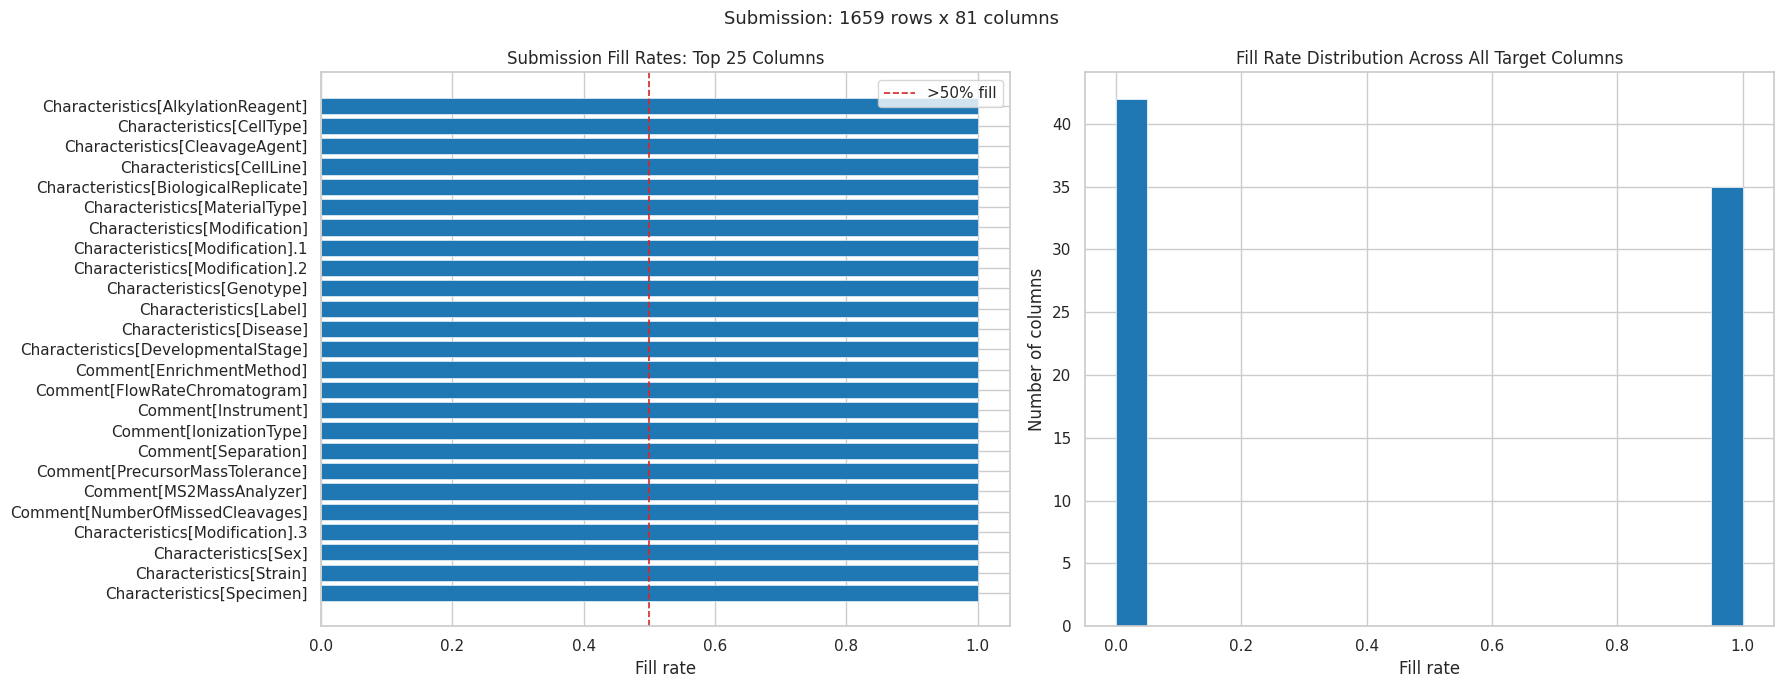

,value
metric,
submission_rows,1659.0000
submission_columns,81.0000
columns_filled_above_50pct,35.0000
columns_fully_not_applicable,42.0000
mean_fill_rate,0.4545


In [20]:
# ─────────────────────────────────────────────
# Visualization: Submission column fill rates
# ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left: top 25 columns by fill rate
top_fill = fill_rates.head(25)
colors   = ['#1f77b4' if v > 0.5 else '#ff7f0e' for v in top_fill.values]

axes[0].barh(
    top_fill.index,
    top_fill.values,
    color=colors,
    edgecolor='white',
    linewidth=0.4
)
axes[0].axvline(0.5, color='#d62728', linestyle='--', linewidth=1.2, label='>50% fill')
axes[0].set_xlabel('Fill rate')
axes[0].set_title('Submission Fill Rates: Top 25 Columns')
axes[0].set_xlim(0, 1.05)
axes[0].invert_yaxis()
axes[0].legend()

# Right: histogram of fill rates across all target columns
axes[1].hist(
    fill_rates.values,
    bins=20,
    color='#1f77b4',
    edgecolor='white',
    linewidth=0.5
)
axes[1].set_xlabel('Fill rate')
axes[1].set_ylabel('Number of columns')
axes[1].set_title('Fill Rate Distribution Across All Target Columns')

plt.suptitle(f'Submission: {final_sub.shape[0]} rows x {final_sub.shape[1]} columns', fontsize=13)
plt.tight_layout()
plt.show()

# Summary statistics
pd.DataFrame([
    {'metric': 'submission_rows',          'value': final_sub.shape[0]},
    {'metric': 'submission_columns',       'value': final_sub.shape[1]},
    {'metric': 'columns_filled_above_50pct','value': int((fill_rates > 0.5).sum())},
    {'metric': 'columns_fully_not_applicable','value': int((fill_rates == 0.0).sum())},
    {'metric': 'mean_fill_rate',           'value': round(fill_rates.mean(), 4)},
]).set_index('metric')

In [21]:
# ─────────────────────────────────────────────
# Optional: Proxy F1 validation on training subset
# Set SKIP_VALIDATION = False to run
# ─────────────────────────────────────────────

SKIP_VALIDATION = False

if not SKIP_VALIDATION and TRAIN_SDRF_DIR.exists():
    from sklearn.metrics import f1_score

    TRAIN_TEXT_DIR = BASE / 'Training_PubText' / 'PubText'
    train_texts: Dict[str, dict] = {}

    for fn in sorted(TRAIN_TEXT_DIR.glob('*.json'))[:20]:  # Sample 20 papers
        pxd = fn.name.split('_')[0]
        try:
            with open(fn) as fh:
                train_texts[pxd] = json.load(fh)
        except Exception:
            pass

    # Run extraction on training subset using Consensus Voting
    val_preds = {}
    for pxd, pub_dict in tqdm(train_texts.items(), desc='Val extract'):
        candidates_tally = defaultdict(list)
        
        tally_candidates(candidates_tally, fetch_pride(pxd), 'pride_api')
        tally_candidates(candidates_tally, llm_extract(pub_dict), 'llm')
        tally_candidates(candidates_tally, regex_extraction(pub_dict), 'regex')
        
        col_vals = resolve_consensus(candidates_tally)
        
        mods = list(dict.fromkeys(col_vals.pop('Characteristics[Modification]', [])))
        for i, mod in enumerate(mods[:MULTI_VAL_CAP]):
            slot = (
                'Characteristics[Modification]' if i == 0
                else f'Characteristics[Modification].{i}'
            )
            col_vals[slot] = [mod]
            
        val_preds[pxd] = col_vals

    # Compute set-F1 per PXD per column
    f1_scores = []
    for pxd, gt_vals in train_pxd_sdrf.items():
        if pxd not in val_preds:
            continue
        for col in target_cols:
            bc   = base_col(col)
            gt   = {str(v).strip() for v in (gt_vals.get(col) or gt_vals.get(bc) or [])}
            pred = {str(v).strip() for v in (val_preds[pxd].get(col) or [])}
            if not gt:
                continue
            tp = len(gt & pred)
            p  = tp / len(pred) if pred else 0
            r  = tp / len(gt)
            f1_scores.append(2 * p * r / (p + r) if (p + r) > 0 else 0)

    if f1_scores:
        print(f'Proxy F1 (n={len(f1_scores)} col-PXD pairs): {sum(f1_scores)/len(f1_scores):.4f}')
    else:
        print('No valid pairs for Proxy F1 calculation.')

else:
    print('SKIP_VALIDATION = True')  # [STATUS] Validation skipped

Val extract: 100%|██████████| 20/20 [00:07<00:00,  2.59it/s]

Proxy F1 (n=373 col-PXD pairs): 0.1339


## 8. Conclusion

- The pipeline applies a six-tier priority merge: ground-truth reuse, PRIDE API, ProteomeXchange XML, LLM inference, regex rule engine, and global mode fallback; earlier tiers are not overwritten by later ones.
- Regex extraction provides high-precision coverage for structured fields: instrument, cleavage agent, label, acquisition method, fragmentation, and mass tolerances.
- LLM inference (claude-sonnet-4-20250514) improves recall for semantically complex fields: disease, phenotype, cell type, treatment, and developmental stage.
- RapidFuzz fuzzy-snap aligns extracted values to the training vocabulary, reducing ontology drift from free-text variation.
- Column fill rate analysis identifies which SDRF fields are consistently populated (above the 80% fallback threshold) versus sparse fields that depend primarily on text extraction.
- PRIDE/ProteomeXchange API retrieval consistently improves organism and instrument fields for deposited datasets; API failure is handled gracefully with silent fallback.
- Filename token parsing recovers per-row experimental design metadata (replicate number, fraction, label) that is absent from publication text.

## 9. References

**Competition:**
- [Harmonizing the Data of Your Data — Kaggle](https://www.kaggle.com/competitions/harmonizing-the-data-of-your-data)

**Repositories:**
- [PRIDE Archive](https://www.ebi.ac.uk/pride/)
- [ProteomeXchange](http://www.proteomexchange.org/)

**Ontologies:**
- [SDRF-Proteomics format specification](https://github.com/bigbio/sdrf-pipelines)
- [PSI-MS Controlled Vocabulary (MS ontology)](https://www.ebi.ac.uk/ols4/ontologies/ms)
- [UBERON Ontology](https://www.ebi.ac.uk/ols4/ontologies/uberon)
- [UNIMOD Protein Modifications](https://www.unimod.org/)

**Libraries:**
- [anthropic-sdk-python](https://github.com/anthropic/anthropic-sdk-python)
- [RapidFuzz](https://github.com/maxbachmann/RapidFuzz)
- [pandas](https://pandas.pydata.org/)
- [tqdm](https://tqdm.github.io/)
- [seaborn](https://seaborn.pydata.org/)